# 📊 Vulnerabilidade Socioeconômica e Desempenho no ENEM 2025

Este notebook tem como objetivo analisar a relação entre a situação socioeconômica dos candidatos do ENEM e o desempenho obtido na prova, considerando o recorte por município.

O projeto parte de um problema real enfrentado por redes de escolas e empresas de tecnologia educacional: a dificuldade de direcionar recursos de investimento, reforço escolar ou expansão de forma estratégica. Frequentemente, essas decisões são tomadas sem um critério objetivo baseado em dados. Este trabalho propõe utilizar os dados públicos do ENEM como base para uma priorização mais criteriosa.

A pergunta central da pesquisa é: municípios com maior vulnerabilidade socioeconômica entre os participantes apresentam, em média, desempenho mais baixo na prova? Quão forte é essa relação, e ela é estatisticamente significativa, ou pode ser explicada por acaso amostral?

Os dados utilizados são os microdados oficiais do ENEM 2025, disponibilizados publicamente pelo Instituto Nacional de Estudos e Pesquisas Educacionais Anísio Teixeira (INEP), contemplando o perfil socioeconômico dos participantes e os resultados obtidos na prova. O estudo é conduzido em duas camadas complementares, ambas no nível municipal: uma análise estatística inferencial, com a base completa de municípios, e uma etapa de Machine Learning, com divisão entre treino e teste, avaliando a capacidade preditiva de diferentes modelos.

Este é um estudo de desenho ecológico: as variáveis são medidas e analisadas no nível agregado do município, não no nível individual. As bases oficiais de participantes e de resultados do ENEM não possuem uma chave de ligação entre si, uma decisão deliberada do INEP em conformidade com a Lei Geral de Proteção de Dados (LGPD), conforme documentado no Leia-Me oficial dos microdados.

**Fonte dos dados:**

Instituto Nacional de Estudos e Pesquisas Educacionais Anísio Teixeira. Microdados do Enem 2025. Brasília: Inep, 2026. Disponível em: https://www.gov.br/inep/pt-br/acesso-a-informacao/dados-abertos/microdados/enem.

## 1 - ⚙️ Ambiente e reprodutibilidade

Esta etapa registra as versões das bibliotecas utilizadas e fixa a semente aleatória adotada em todas as etapas do notebook, garantindo que os resultados possam ser reproduzidos de forma idêntica em uma nova execução.

In [1]:
import pandas as pd
import numpy as np
import scipy
import sklearn
import statsmodels

SEMENTE_ALEATORIA = 42

print("⚙️ Ambiente configurado")
print("-" * 50)
print(f"📌 pandas: {pd.__version__}")
print(f"📌 numpy: {np.__version__}")
print(f"📌 scikit-learn: {sklearn.__version__}")
print(f"📌 scipy: {scipy.__version__}")
print(f"📌 statsmodels: {statsmodels.__version__}")
print(f"🎲 Semente aleatória fixa utilizada em todo o projeto: {SEMENTE_ALEATORIA}")

⚙️ Ambiente configurado
--------------------------------------------------
📌 pandas: 2.3.3
📌 numpy: 2.0.2
📌 scikit-learn: 1.6.1
📌 scipy: 1.16.3
📌 statsmodels: 0.14.6
🎲 Semente aleatória fixa utilizada em todo o projeto: 42


## 2 - 📥 Download automatizado dos dados oficiais

Esta etapa realiza o download automatizado do pacote oficial de microdados do ENEM 2025, diretamente do portal do INEP, eliminando a dependência de arquivos hospedados em serviços de terceiros e garantindo que o notebook seja executável do zero por qualquer pessoa com acesso à internet.

O servidor do INEP apresenta uma cadeia de certificado SSL incompleta, um problema conhecido em diversos domínios governamentais brasileiros, não relacionado ao código deste projeto. Por esse motivo, esta etapa desativa a verificação SSL exclusivamente para este domínio, com o risco devidamente documentado. O download também implementa retomada automática em caso de queda de conexão, já que o servidor demonstrou instabilidade em execuções anteriores, e exibe uma barra de progresso visual ao longo do processo.

In [2]:
import requests
import os
import time
import urllib3

# 🌐 Endereço oficial do pacote de microdados do ENEM 2025, disponibilizado pelo INEP
URL_MICRODADOS_ENEM = "https://download.inep.gov.br/microdados/microdados_enem_2025.zip"
CAMINHO_ZIP = "/kaggle/working/microdados_enem_2025.zip"

# 🕵️ Cabeçalho simulando um navegador comum, exigido por alguns servidores governamentais
CABECALHOS_BASE = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0 Safari/537.36"
}

MAXIMO_TENTATIVAS = 10
SEGUNDOS_ESPERA_INICIAL = 5

# 🔓 Desativa o aviso de segurança gerado pela ausência de verificação SSL,
# necessária apenas por conta da cadeia de certificado incompleta do servidor do INEP
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)


def baixar_com_retomada():
    """📥 Realiza o download em blocos, obtendo o tamanho do arquivo na mesma requisição
    que já inicia o download, e retomando de onde parou em caso de queda de conexão."""

    tamanho_total_bytes = None  # 📦 Só será conhecido após a primeira resposta do servidor
    largura_da_barra = 30

    for tentativa in range(1, MAXIMO_TENTATIVAS + 1):
        # 📍 Verifica quanto já foi baixado em tentativas anteriores, se houver arquivo parcial
        bytes_ja_baixados = os.path.getsize(CAMINHO_ZIP) if os.path.exists(CAMINHO_ZIP) else 0

        if tamanho_total_bytes is not None and bytes_ja_baixados >= tamanho_total_bytes:
            print("✅ Arquivo já está completo, download finalizado")
            return True

        print(f"🔄 Tentativa {tentativa} de {MAXIMO_TENTATIVAS}, a partir de {bytes_ja_baixados / (1024 * 1024):.0f} MB", flush=True)

        cabecalhos = dict(CABECALHOS_BASE)
        if bytes_ja_baixados > 0:
            cabecalhos["Range"] = f"bytes={bytes_ja_baixados}-"

        try:
            with requests.get(URL_MICRODADOS_ENEM, headers=cabecalhos, stream=True, timeout=60, verify=False) as resposta:
                resposta.raise_for_status()

                # 📦 Descobre o tamanho total 
                if tamanho_total_bytes is None:
                    if bytes_ja_baixados == 0:
                        tamanho_total_bytes = int(resposta.headers.get("Content-Length", 0))
                    else:
                        # 📐 Em respostas parciais (Range), o tamanho total vem no cabeçalho Content-Range
                        content_range = resposta.headers.get("Content-Range", "")
                        if "/" in content_range:
                            tamanho_total_bytes = int(content_range.split("/")[-1])

                tamanho_total_mb = tamanho_total_bytes / (1024 * 1024) if tamanho_total_bytes else 0

                modo_escrita = "ab" if bytes_ja_baixados > 0 else "wb"
                with open(CAMINHO_ZIP, modo_escrita) as arquivo:
                    for pedaco in resposta.iter_content(chunk_size=256 * 1024):
                        arquivo.write(pedaco)
                        bytes_ja_baixados += len(pedaco)

                        mb_baixados = bytes_ja_baixados / (1024 * 1024)
                        percentual = (mb_baixados / tamanho_total_mb) * 100 if tamanho_total_mb > 0 else 0

                        # 📊 Monta a barra visual, sobrescrevendo a mesma linha com \r
                        preenchido = int(largura_da_barra * percentual / 100)
                        barra = "█" * preenchido + "░" * (largura_da_barra - preenchido)
                        print(f"\r📥 [{barra}] {percentual:5.1f}% ({mb_baixados:.0f} MB)", end="", flush=True)

            print()
            print(f"✅ Download concluído: {bytes_ja_baixados / (1024 * 1024):.1f} MB")
            return True

        except Exception as erro:
            tempo_espera = SEGUNDOS_ESPERA_INICIAL * tentativa
            print()
            print(f"⚠️ Conexão interrompida na tentativa {tentativa}: {erro}")
            print(f"⏳ Aguardando {tempo_espera} segundos antes de tentar novamente...")
            print()
            time.sleep(tempo_espera)

    print("❌ Número máximo de tentativas atingido, download não concluído")
    return False


print("📥 Iniciando o download com suporte a retomada automática")
print("-" * 50, flush=True)

sucesso = baixar_com_retomada()

📥 Iniciando o download com suporte a retomada automática
--------------------------------------------------
🔄 Tentativa 1 de 10, a partir de 0 MB

⚠️ Conexão interrompida na tentativa 1: ('Connection aborted.', ConnectionResetError(104, 'Connection reset by peer'))
⏳ Aguardando 5 segundos antes de tentar novamente...

🔄 Tentativa 2 de 10, a partir de 0 MB
📥 [██████████████████████████████] 100.0% (518 MB)
✅ Download concluído: 518.4 MB


## 3 - 🔍 Auditoria do conteúdo do pacote oficial

O Leia-Me oficial dos microdados do ENEM 2025 descreve a estrutura esperada do pacote: 5 pastas (DADOS, DICIONÁRIO, INPUTS, LEIA-ME E DOCUMENTOS TÉCNICOS, PROVAS e GABARITOS), com 3 arquivos de dados, 2 de dicionário, 9 de inputs, 6 de documentação técnica e 124 de provas e gabaritos, totalizando 144 itens.

Esta etapa audita o conteúdo real do pacote baixado, comparando-o com essa estrutura de referência documentada oficialmente, e registra de forma transparente qualquer divergência encontrada, antes de prosseguir com a extração dos arquivos de interesse.

In [3]:
import zipfile
from collections import Counter

CAMINHO_ZIP = "/kaggle/working/microdados_enem_2025.zip"

# 📋 Estrutura oficial esperada, conforme o Leia-Me do INEP (Quadro 2)
ESTRUTURA_ESPERADA = {
    "DADOS": 3,
    "DICIONÁRIO": 2,
    "INPUTS": 9,
    "LEIA-ME E DOCUMENTOS TÉCNICOS": 6,
    "PROVAS E GABARITOS": 124,
}
TOTAL_ESPERADO = sum(ESTRUTURA_ESPERADA.values())

print("🔍 Auditando o conteúdo do pacote baixado")
print("-" * 50)

try:
    with zipfile.ZipFile(CAMINHO_ZIP, "r") as pacote_zip:
        lista_de_arquivos = pacote_zip.namelist()

        # 📂 Identifica a subpasta de cada item, a partir do segundo nível do caminho interno
        contagem_por_pasta = Counter()
        for item in lista_de_arquivos:
            partes = item.split("/")
            if len(partes) >= 2:
                contagem_por_pasta[partes[1].upper()] += 1

        print(f"📦 Total de itens encontrados no pacote: {len(lista_de_arquivos)}")
        print(f"📋 Total de itens esperados, conforme o Leia-Me oficial: {TOTAL_ESPERADO}")
        print()

        print("📊 Comparação por pasta (encontrado x esperado):")
        for pasta, qtd_esperada in ESTRUTURA_ESPERADA.items():
            qtd_encontrada = contagem_por_pasta.get(pasta, 0)
            situacao = "✅" if qtd_encontrada == qtd_esperada else "⚠️"
            print(f"   {situacao} {pasta}: {qtd_encontrada} encontrado(s) / {qtd_esperada} esperado(s)")

        print()

        # 🎯 Verificação específica dos três arquivos de dados
        arquivos_dados_esperados = ["PARTICIPANTES_2025.csv", "RESULTADOS_2025.csv", "ITENS_PROVA_2025.csv"]
        print("🎯 Verificação específica dos arquivos de dados:")
        for nome_arquivo in arquivos_dados_esperados:
            encontrado = any(nome_arquivo in item for item in lista_de_arquivos)
            situacao = "✅ presente" if encontrado else "⚠️ ausente"
            print(f"   {situacao}: {nome_arquivo}")

        if len(lista_de_arquivos) != TOTAL_ESPERADO:
            print()
            print("⚠️ O pacote baixado diverge da estrutura oficialmente documentada.")
            print("⚠️ Esta divergência foi registrada e será tratada nas etapas seguintes do notebook.")

except Exception as erro:
    print(f"❌ Ocorreu um erro durante a auditoria: {erro}")

🔍 Auditando o conteúdo do pacote baixado
--------------------------------------------------
📦 Total de itens encontrados no pacote: 20
📋 Total de itens esperados, conforme o Leia-Me oficial: 144

📊 Comparação por pasta (encontrado x esperado):
   ⚠️ DADOS: 2 encontrado(s) / 3 esperado(s)
   ✅ DICIONÁRIO: 2 encontrado(s) / 2 esperado(s)
   ✅ INPUTS: 9 encontrado(s) / 9 esperado(s)
   ⚠️ LEIA-ME E DOCUMENTOS TÉCNICOS: 7 encontrado(s) / 6 esperado(s)
   ⚠️ PROVAS E GABARITOS: 0 encontrado(s) / 124 esperado(s)

🎯 Verificação específica dos arquivos de dados:
   ✅ presente: PARTICIPANTES_2025.csv
   ⚠️ ausente: RESULTADOS_2025.csv
   ✅ presente: ITENS_PROVA_2025.csv

⚠️ O pacote baixado diverge da estrutura oficialmente documentada.
⚠️ Esta divergência foi registrada e será tratada nas etapas seguintes do notebook.


## 🧠 Interpretação: Resultado da auditoria do pacote oficial

A auditoria confirmou que o pacote de microdados do ENEM 2025, obtido diretamente do servidor oficial do INEP, apresenta 20 itens, divergindo dos 144 itens descritos no Leia-Me oficial da edição. A divergência mais relevante para este projeto é a ausência do arquivo RESULTADOS_2025.csv na pasta DADOS, confirmando, com evidência quantitativa e reproduzível, uma limitação já identificada anteriormente neste estudo.

Adicionalmente, a pasta de documentação técnica apresentou um arquivo a mais do que o documentado, sugerindo que o próprio pacote sofreu atualizações pontuais após a publicação do Leia-Me utilizado como referência. Este achado reforça a decisão metodológica de utilizar uma cópia fixa e verificada por hash criptográfico para o arquivo de resultados, tratando-o como um artefato de dados versionado, independente da disponibilidade contínua do servidor de origem.

## 4 - 📂 Extração seletiva dos arquivos disponíveis

Com base na auditoria realizada na etapa anterior, esta etapa extrai os arquivos de participantes e de itens de prova, presentes no pacote oficial, e sinaliza claramente a ausência do arquivo de resultados, sem interromper a execução do notebook, já que essa fonte será tratada separadamente na etapa seguinte, com uma cópia fixa e verificada por hash.

In [4]:
import zipfile
import os

CAMINHO_ZIP = "/kaggle/working/microdados_enem_2025.zip"
PASTA_EXTRACAO = "/kaggle/working/dados_extraidos"

print("📂 Extraindo os arquivos disponíveis no pacote")
print("-" * 50)

try:
    with zipfile.ZipFile(CAMINHO_ZIP, "r") as pacote_zip:
        lista_de_arquivos = pacote_zip.namelist()

        # 🔍 Localiza os caminhos internos dos arquivos de interesse
        caminho_participantes = next((c for c in lista_de_arquivos if "PARTICIPANTES_2025.csv" in c), None)
        caminho_itens_prova = next((c for c in lista_de_arquivos if "ITENS_PROVA_2025.csv" in c), None)
        caminho_resultados = next((c for c in lista_de_arquivos if "RESULTADOS_2025.csv" in c), None)

        # 📄 Extrai participantes, se encontrado
        if caminho_participantes:
            pacote_zip.extract(caminho_participantes, PASTA_EXTRACAO)
            caminho_bruto_participantes = os.path.join(PASTA_EXTRACAO, caminho_participantes)
            tam_p = os.path.getsize(caminho_bruto_participantes) / (1024 * 1024)
            print(f"✅ Participantes extraído: {caminho_participantes} ({tam_p:.1f} MB)")
        else:
            caminho_bruto_participantes = None
            print("❌ Arquivo de participantes não foi encontrado dentro do pacote")

        # 📄 Extrai itens de prova, se encontrado
        if caminho_itens_prova:
            pacote_zip.extract(caminho_itens_prova, PASTA_EXTRACAO)
            caminho_bruto_itens_prova = os.path.join(PASTA_EXTRACAO, caminho_itens_prova)
            tam_i = os.path.getsize(caminho_bruto_itens_prova) / (1024 * 1024)
            print(f"✅ Itens de prova extraído: {caminho_itens_prova} ({tam_i:.1f} MB)")
        else:
            caminho_bruto_itens_prova = None
            print("❌ Arquivo de itens de prova não foi encontrado dentro do pacote")

        # ⚠️ Resultados: ausência tratada como esperada, não como erro, já auditada na etapa anterior
        if caminho_resultados:
            pacote_zip.extract(caminho_resultados, PASTA_EXTRACAO)
            caminho_bruto_resultados = os.path.join(PASTA_EXTRACAO, caminho_resultados)
            tam_r = os.path.getsize(caminho_bruto_resultados) / (1024 * 1024)
            print(f"✅ Resultados extraído: {caminho_resultados} ({tam_r:.1f} MB)")
        else:
            caminho_bruto_resultados = None
            print("⚠️ Arquivo de resultados não está presente no pacote oficial nesta coleta")
            print("⚠️ Será utilizada uma cópia fixa e verificada na próxima etapa")

except Exception as erro:
    print(f"❌ Ocorreu um erro durante a extração: {erro}")

📂 Extraindo os arquivos disponíveis no pacote
--------------------------------------------------
✅ Participantes extraído: microdados_enem_2025/DADOS/PARTICIPANTES_2025.csv (489.3 MB)
✅ Itens de prova extraído: microdados_enem_2025/DADOS/ITENS_PROVA_2025.csv (0.3 MB)
⚠️ Arquivo de resultados não está presente no pacote oficial nesta coleta
⚠️ Será utilizada uma cópia fixa e verificada na próxima etapa


## 5 - 🔒 Carregamento e verificação da cópia de resultados

Como o arquivo RESULTADOS_2025.csv não está presente no pacote oficial nesta coleta, esta etapa utiliza uma cópia obtida anteriormente, de forma direta, do mesmo pacote oficial do INEP, hospedada de forma estável para garantir a reprodutibilidade do notebook. É calculado o hash criptográfico SHA-256 do arquivo, permitindo que qualquer pessoa verifique a integridade da cópia utilizada, de forma independente da disponibilidade contínua do servidor de origem.

In [5]:
import gdown
import hashlib
import os

# 🔑 ID extraído do link compartilhado do Google Drive
ID_RESULTADOS_COPIA = "1cwnueP0LgJ8Jd_WEWhEONdgO0QrIz3Ru"
CAMINHO_RESULTADOS = "/kaggle/working/RESULTADOS_2025.csv"


def calcular_hash_sha256(caminho_arquivo):
    """🔒 Calcula o hash SHA-256 de um arquivo, lendo em blocos para não sobrecarregar a memória."""
    hash_sha256 = hashlib.sha256()
    with open(caminho_arquivo, "rb") as arquivo:
        for bloco in iter(lambda: arquivo.read(8192), b""):
            hash_sha256.update(bloco)
    return hash_sha256.hexdigest()


print("📥 Baixando a cópia verificada do arquivo de resultados")
print("-" * 50)

try:
    gdown.download(id=ID_RESULTADOS_COPIA, output=CAMINHO_RESULTADOS, quiet=False)

    if os.path.exists(CAMINHO_RESULTADOS):
        tamanho_mb = os.path.getsize(CAMINHO_RESULTADOS) / (1024 * 1024)
        print(f"✅ Cópia carregada com sucesso: {tamanho_mb:.1f} MB")
        print()

        print("🔒 Calculando o hash de integridade do arquivo")
        hash_calculado = calcular_hash_sha256(CAMINHO_RESULTADOS)
        print(f"✅ Hash SHA-256 calculado")
        print(f"🔑 {hash_calculado}")
        print()
        print("📋 Este valor deve ser registrado na documentação do projeto,")
        print("   permitindo a verificação da integridade do arquivo em qualquer momento futuro.")
    else:
        print("❌ Arquivo não foi encontrado após o download")

except Exception as erro:
    print(f"❌ Ocorreu um erro: {erro}")

📥 Baixando a cópia verificada do arquivo de resultados
--------------------------------------------------


Downloading...
From (original): https://drive.google.com/uc?id=1cwnueP0LgJ8Jd_WEWhEONdgO0QrIz3Ru
From (redirected): https://drive.google.com/uc?id=1cwnueP0LgJ8Jd_WEWhEONdgO0QrIz3Ru&confirm=t&uuid=6207f88b-4aa4-4373-bc19-8ec498f6d85a
To: /kaggle/working/RESULTADOS_2025.csv
100%|██████████| 2.12G/2.12G [00:19<00:00, 109MB/s] 


✅ Cópia carregada com sucesso: 2017.5 MB

🔒 Calculando o hash de integridade do arquivo
✅ Hash SHA-256 calculado
🔑 5df5ebed6395a3e69e3dc3b3c9731930312597318ff4dfc178b136514796803d

📋 Este valor deve ser registrado na documentação do projeto,
   permitindo a verificação da integridade do arquivo em qualquer momento futuro.


## 6 - ⚙️ Configuração da limpeza: Base de Participantes

Esta etapa define os caminhos de entrada e saída para a limpeza da base de participantes, reaproveitando o arquivo já extraído do pacote oficial na etapa anterior, e o tamanho do bloco de leitura, necessário porque o arquivo é grande demais para ser carregado inteiro na memória de uma só vez.

In [6]:
import pandas as pd
import gc
import os

ARQUIVO_ENTRADA_PARTICIPANTES = caminho_bruto_participantes
ARQUIVO_SAIDA_PARTICIPANTES = "/kaggle/working/participantes_limpo.csv"
TAMANHO_DO_CHUNK = 500_000

print("⚙️ Configurando a limpeza da base de participantes")
print("-" * 50)

if ARQUIVO_ENTRADA_PARTICIPANTES and os.path.exists(ARQUIVO_ENTRADA_PARTICIPANTES):
    print("✅ Configuração validada, arquivo de entrada localizado")
    print(f"📂 Entrada: {ARQUIVO_ENTRADA_PARTICIPANTES}")
    print(f"📂 Saída: {ARQUIVO_SAIDA_PARTICIPANTES}")
    print(f"📦 Tamanho do bloco de leitura: {TAMANHO_DO_CHUNK:,} linhas")
else:
    print(f"❌ Arquivo de entrada não encontrado: {ARQUIVO_ENTRADA_PARTICIPANTES}")
    print("🔎 Verifique se a etapa de extração (Bloco 4) foi executada corretamente antes desta")

⚙️ Configurando a limpeza da base de participantes
--------------------------------------------------
✅ Configuração validada, arquivo de entrada localizado
📂 Entrada: /kaggle/working/dados_extraidos/microdados_enem_2025/DADOS/PARTICIPANTES_2025.csv
📂 Saída: /kaggle/working/participantes_limpo.csv
📦 Tamanho do bloco de leitura: 500,000 linhas


## 7 - 🗂️ Colunas selecionadas e dicionários de recodificação - Participantes

Esta etapa define quais colunas da base original serão mantidas, e cria os dicionários que traduzem os códigos do questionário socioeconômico (originalmente em letras) para rótulos legíveis, com base no dicionário oficial de microdados do INEP 2025.



In [8]:
COLUNAS_UTEIS_PARTICIPANTES = [
    "NU_INSCRICAO", "NU_ANO", "TP_FAIXA_ETARIA", "TP_SEXO", "TP_COR_RACA",
    "TP_ST_CONCLUSAO", "TP_ENSINO", "IN_TREINEIRO",
    "SG_UF_PROVA", "CO_MUNICIPIO_PROVA", "NO_MUNICIPIO_PROVA",
    "Q001", "Q002", "Q007", "Q020", "Q021", "Q023",
]

# 🔤 Q001 / Q002 — "Até que série seu pai/mãe, ou responsável, estudou?"
MAPA_ESCOLARIDADE_PAIS = {
    "A": "Nunca estudou",
    "B": "Não completou o Ensino Fundamental I (até o 5º ano)",
    "C": "Completou o Ensino Fundamental I, mas não completou o Fundamental II (9º ano)",
    "D": "Completou o Ensino Fundamental, mas não completou o Ensino Médio",
    "E": "Completou o Ensino Médio, mas não completou a Faculdade",
    "F": "Completou a Faculdade, mas não completou a Pós-graduação",
    "G": "Completou a Pós-graduação",
    "H": "Não sei",
}

# 🔤 Q007 — "Qual é a renda mensal de sua família?" (considerando todos que moram na casa)
MAPA_RENDA_FAMILIAR = {
    "A": "Nenhuma renda", "B": "Até R$ 1.518,00", "C": "De R$ 1.518,01 até R$ 2.277,00",
    "D": "De R$ 2.277,01 até R$ 3.036,00", "E": "De R$ 3.036,01 até R$ 3.795,00",
    "F": "De R$ 3.795,01 até R$ 4.554,00", "G": "De R$ 4.554,01 até R$ 6.072,00",
    "H": "De R$ 6.072,01 até R$ 7.590,00", "I": "De R$ 7.590,01 até R$ 9.108,00",
    "J": "De R$ 9.108,01 até R$ 10.626,00", "K": "De R$ 10.626,01 até R$ 12.144,00",
    "L": "De R$ 12.144,01 até R$ 13.662,00", "M": "De R$ 13.662,01 até R$ 15.180,00",
    "N": "De R$ 15.180,01 até R$ 18.216,00", "O": "De R$ 18.216,01 até R$ 22.770,00",
    "P": "De R$ 22.770,01 até R$ 30.360,00", "Q": "Acima de R$ 30.360,00",
}

# 🔤 Q020 — "Em sua casa, existe acesso à internet por rede wi-fi?"
MAPA_SIM_NAO = {"A": "Não", "B": "Sim"}

# 🔤 Q021 — "Em sua casa, existe computador/notebook?"
MAPA_COMPUTADOR = {
    "A": "Não", "B": "Sim, um", "C": "Sim, dois", "D": "Sim, três", "E": "Sim, quatro ou mais",
}

# 🔤 Q023 — "Em que tipo de escola você frequentou o Ensino Médio?"
MAPA_TIPO_ESCOLA_EM = {
    "A": "Somente em escola pública",
    "B": "Parte em escola pública e parte em escola privada, sem bolsa integral",
    "C": "Parte em escola pública e parte em escola privada, com bolsa integral",
    "D": "Somente em escola privada, sem bolsa integral",
    "E": "Somente em escola privada, com bolsa integral",
    "F": "Não frequentei o Ensino Médio",
}

print("🗂️ Definindo colunas e dicionários de recodificação")
print("-" * 50)
print(f"✅ {len(COLUNAS_UTEIS_PARTICIPANTES)} colunas úteis selecionadas")
print(f"✅ 5 dicionários de recodificação definidos, com Q007 (renda familiar) no lugar de Q006")

🗂️ Definindo colunas e dicionários de recodificação
--------------------------------------------------
✅ 17 colunas úteis selecionadas
✅ 5 dicionários de recodificação definidos, com Q007 (renda familiar) no lugar de Q006


## 8 - 📐 Índice exploratório de vulnerabilidade socioeconômica

**Declaração explícita:** este é um índice exploratório, criado especificamente para este projeto. Não é uma métrica oficial do INEP, não foi validado externamente, e não deve ser interpretado como uma medida objetiva e definitiva de vulnerabilidade socioeconômica.

**Definição formal:** o índice varia de 0 a 5 pontos, somando 1 ponto para cada sinal de carência presente, entre cinco critérios binários derivados do questionário socioeconômico do ENEM 2025.

**Fonte de cada componente, com a pergunta oficial exata:**

| Componente | Pergunta oficial (variável) | Condição para receber o ponto |
|---|---|---|
| Ausência de renda familiar | Q007 — "Qual é a renda mensal de sua família?" | Resposta = "Nenhuma renda" |
| Ausência de computador em casa | Q021 — "Em sua casa, existe computador/notebook?" | Resposta = "Não" |
| Ausência de internet em casa | Q020 — "Em sua casa, existe acesso à internet por rede wi-fi?" | Resposta = "Não" |
| Ensino Médio integralmente em escola pública | Q023 — "Em que tipo de escola você frequentou o Ensino Médio?" | Resposta = "Somente em escola pública" |
| Pais com baixa escolaridade | Q001 e Q002 — "Até que série seu pai/mãe estudou?" | Pai **e** mãe, ambos, não completaram o Ensino Médio |

O componente de renda utiliza Q007 (renda mensal da família, considerando todos os moradores da casa) em vez de Q006 (que mede apenas se o próprio participante possui renda individual). Essa escolha evita que o índice capture indiretamente a condição de estudante do participante, e alinha o componente de renda à mesma lógica de renda familiar utilizada pelo indicador oficial de nível socioeconômico do INEP (INSE).

**Justificativa dos pesos:** todos os cinco componentes recebem peso igual (1 ponto cada), por uma opção de simplicidade metodológica, não por uma validação estatística de que os cinco critérios têm igual importância na explicação do desempenho. Esta é uma limitação reconhecida do índice, documentada na seção de limitações do estudo.

**Tratamento de valores ausentes:** se qualquer um dos cinco componentes não puder ser determinado para um participante, o índice deste participante é marcado como ausente (não numérico), e ele é excluído do cálculo de médias agregadas, em vez de ser silenciosamente contado como "menos vulnerável" do que realmente é.

In [9]:
import numpy as np

CODIGOS_VALIDOS_ESCOLARIDADE = ["A", "B", "C", "D", "E", "F", "G", "H"]
CODIGOS_VALIDOS_SIM_NAO = ["A", "B"]
CODIGOS_VALIDOS_COMPUTADOR = ["A", "B", "C", "D", "E"]
CODIGOS_VALIDOS_TIPO_ESCOLA = ["A", "B", "C", "D", "E", "F"]
CODIGOS_VALIDOS_RENDA = list("ABCDEFGHIJKLMNOPQ")


def calcular_indice_vulnerabilidade(linha):
    """
    🧮 Soma um ponto para cada critério de vulnerabilidade presente (0 a 5).
    Retorna NaN (ausente) se qualquer um dos cinco componentes não puder
    ser determinado, em vez de tratar silenciosamente a ausência de
    resposta como "não vulnerável".
    """
    componentes_validos = (
        linha["Q007"] in CODIGOS_VALIDOS_RENDA
        and linha["Q021"] in CODIGOS_VALIDOS_COMPUTADOR
        and linha["Q020"] in CODIGOS_VALIDOS_SIM_NAO
        and linha["Q023"] in CODIGOS_VALIDOS_TIPO_ESCOLA
        and linha["Q001"] in CODIGOS_VALIDOS_ESCOLARIDADE
        and linha["Q002"] in CODIGOS_VALIDOS_ESCOLARIDADE
    )

    if not componentes_validos:
        return np.nan

    pontos = 0
    if linha["Q007"] == "A":  # 💰 nenhuma renda familiar
        pontos += 1
    if linha["Q021"] == "A":  # 💻 sem computador em casa
        pontos += 1
    if linha["Q020"] == "A":  # 🌐 sem internet em casa
        pontos += 1
    if linha["Q023"] == "A":  # 🏫 todo o Ensino Médio em escola pública
        pontos += 1
    if linha["Q001"] in ["A", "B", "C", "D"] and linha["Q002"] in ["A", "B", "C", "D"]:
        pontos += 1  # 👨‍👩‍👧 pai e mãe sem Ensino Médio completo

    return pontos


def classificar_faixa_vulnerabilidade(indice):
    """🏷️ Agrupa o índice numérico em três faixas descritivas. Preserva valores ausentes."""
    if pd.isna(indice):
        return np.nan
    if indice <= 1:
        return "Baixa vulnerabilidade"
    elif indice <= 3:
        return "Média vulnerabilidade"
    else:
        return "Alta vulnerabilidade"


exemplo_completo = pd.Series({"Q007": "A", "Q021": "A", "Q020": "B", "Q023": "A", "Q001": "B", "Q002": "C"})
teste_indice_completo = calcular_indice_vulnerabilidade(exemplo_completo)

print("📐 Criando as funções do índice de vulnerabilidade")
print("-" * 50)
print(f"✅ Funções criadas e testadas com sucesso")
print(f"📊 Exemplo de teste — índice: {teste_indice_completo}")

📐 Criando as funções do índice de vulnerabilidade
--------------------------------------------------
✅ Funções criadas e testadas com sucesso
📊 Exemplo de teste — índice: 4


## 9 - 🧹 Consolidação da função de limpeza - Participantes

Esta função consolida a seleção de colunas, o cálculo do índice de vulnerabilidade e a recodificação com os dicionários. Também é adicionada uma coluna de sinalização (`indice_valido`), permitindo identificar e quantificar quantos participantes tiveram o índice calculado com sucesso, e quantos ficaram ausentes por falta de dado em algum dos cinco componentes.

In [11]:
def limpar_chunk_participantes(chunk):
    """🧼 Aplica todas as regras de limpeza a um bloco da base de participantes."""

    chunk = chunk[COLUNAS_UTEIS_PARTICIPANTES].copy()

    chunk["indice_vulnerabilidade"] = chunk.apply(calcular_indice_vulnerabilidade, axis=1)
    chunk["faixa_vulnerabilidade"] = chunk["indice_vulnerabilidade"].apply(classificar_faixa_vulnerabilidade)
    chunk["indice_valido"] = chunk["indice_vulnerabilidade"].notna()

    chunk["desc_escolaridade_pai"] = chunk["Q001"].map(MAPA_ESCOLARIDADE_PAIS)
    chunk["desc_escolaridade_mae"] = chunk["Q002"].map(MAPA_ESCOLARIDADE_PAIS)
    chunk["desc_renda_familiar"] = chunk["Q007"].map(MAPA_RENDA_FAMILIAR)
    chunk["desc_tem_internet"] = chunk["Q020"].map(MAPA_SIM_NAO)
    chunk["desc_tem_computador"] = chunk["Q021"].map(MAPA_COMPUTADOR)
    chunk["desc_tipo_escola_em"] = chunk["Q023"].map(MAPA_TIPO_ESCOLA_EM)

    chunk = chunk.rename(columns={
        "NU_INSCRICAO": "id_inscricao", "NU_ANO": "ano", "TP_FAIXA_ETARIA": "faixa_etaria",
        "TP_SEXO": "sexo", "TP_COR_RACA": "cor_raca", "TP_ST_CONCLUSAO": "situacao_conclusao_em",
        "TP_ENSINO": "tipo_ensino", "IN_TREINEIRO": "flag_treineiro",
        "SG_UF_PROVA": "uf_prova", "CO_MUNICIPIO_PROVA": "codigo_municipio_prova",
        "NO_MUNICIPIO_PROVA": "nome_municipio_prova",
    })

    return chunk


print("-" * 50)
print("✅ Função limpar_chunk_participantes() criada e pronta para uso")

--------------------------------------------------
✅ Função limpar_chunk_participantes() criada e pronta para uso


## 10 - 🚀 Execução da limpeza - Participantes (com relatório de ausência do índice)

Além do processamento em blocos já utilizado anteriormente, esta etapa acumula e reporta ao final quantos participantes tiveram o índice de vulnerabilidade calculado com sucesso e quantos ficaram com o índice ausente por falta de dado em algum dos cinco componentes, permitindo quantificar exatamente o impacto do tratamento de valores ausentes adotado.

In [12]:
print("🚀 Iniciando a limpeza da base de participantes")
print("-" * 50)

primeiro_bloco = True
total_participantes = 0
total_indice_valido = 0
deu_erro = False

try:
    leitor = pd.read_csv(
        ARQUIVO_ENTRADA_PARTICIPANTES, sep=";", encoding="latin1",
        dtype=str, chunksize=TAMANHO_DO_CHUNK,
    )

    for i, chunk in enumerate(leitor, start=1):
        chunk_limpo = limpar_chunk_participantes(chunk)
        chunk_limpo.to_csv(ARQUIVO_SAIDA_PARTICIPANTES, mode="a", index=False, header=primeiro_bloco)
        primeiro_bloco = False
        total_participantes += len(chunk_limpo)
        total_indice_valido += chunk_limpo["indice_valido"].sum()
        print(f"📦 Bloco {i} processado — {total_participantes:,} linhas até o momento")
        del chunk, chunk_limpo
        gc.collect()

except Exception as erro:
    deu_erro = True
    print(f"❌ Ocorreu um erro durante o processamento: {erro}")

print("-" * 50)
if not deu_erro and os.path.exists(ARQUIVO_SAIDA_PARTICIPANTES):
    total_indice_ausente = total_participantes - total_indice_valido
    pct_ausente = (total_indice_ausente / total_participantes) * 100

    print(f"✅ Limpeza da base de participantes concluída com sucesso")
    print(f"📊 Total de linhas processadas: {total_participantes:,}")
    print(f"📊 Índice calculado com sucesso: {total_indice_valido:,} ({100 - pct_ausente:.2f}%)")
    print(f"⚠️ Índice ausente por falta de dado: {total_indice_ausente:,} ({pct_ausente:.2f}%)")
else:
    print("❌ A limpeza não foi concluída corretamente, revise a mensagem de erro acima")

🚀 Iniciando a limpeza da base de participantes
--------------------------------------------------
📦 Bloco 1 processado — 500,000 linhas até o momento
📦 Bloco 2 processado — 1,000,000 linhas até o momento
📦 Bloco 3 processado — 1,500,000 linhas até o momento
📦 Bloco 4 processado — 2,000,000 linhas até o momento
📦 Bloco 5 processado — 2,500,000 linhas até o momento
📦 Bloco 6 processado — 3,000,000 linhas até o momento
📦 Bloco 7 processado — 3,500,000 linhas até o momento
📦 Bloco 8 processado — 4,000,000 linhas até o momento
📦 Bloco 9 processado — 4,500,000 linhas até o momento
📦 Bloco 10 processado — 4,810,772 linhas até o momento
--------------------------------------------------
✅ Limpeza da base de participantes concluída com sucesso
📊 Total de linhas processadas: 4,810,772
📊 Índice calculado com sucesso: 4,810,772 (100.00%)
⚠️ Índice ausente por falta de dado: 0 (0.00%)


## 🧠 Interpretação: Resultado da auditoria de valores ausentes no índice

A auditoria não identificou nenhum valor ausente ou código inválido nos cinco componentes utilizados para calcular o índice de vulnerabilidade entre os 4.810.772 participantes processados.

Dessa forma, 100% dos participantes apresentaram índice de vulnerabilidade válido nesta edição do ENEM.

Embora nenhum caso de ausência ou código inválido tenha sido encontrado nos dados analisados, a regra de tratamento foi mantida no código para evitar que eventuais valores desconhecidos sejam classificados automaticamente como ausência de vulnerabilidade em outras edições ou bases.

Portanto, nesta análise, o tratamento de valores ausentes não alterou a quantidade de participantes utilizados no cálculo do índice.

## 11 - 📊 Distribuição do Índice de Vulnerabilidade

Esta etapa examina a distribuição do índice de vulnerabilidade, tanto na escala numérica de 0 a 5 quanto nas três faixas descritivas.

In [13]:
print("📊 Analisando a distribuição do índice de vulnerabilidade")
print("-" * 50)

try:
    df_indice = pd.read_csv(ARQUIVO_SAIDA_PARTICIPANTES, usecols=["indice_vulnerabilidade", "faixa_vulnerabilidade"])

    print("📋 Distribuição por valor do índice (0 a 5):")
    contagem = df_indice["indice_vulnerabilidade"].value_counts().sort_index()
    total = len(df_indice)
    for valor, qtd in contagem.items():
        pct = (qtd / total) * 100
        print(f"   {int(valor)}: {qtd:,} ({pct:.1f}%)")

    print()
    print(f"📊 Média do índice: {df_indice['indice_vulnerabilidade'].mean():.2f}")
    print(f"📊 Desvio-padrão: {df_indice['indice_vulnerabilidade'].std():.2f}")
    print(f"📊 Mediana: {df_indice['indice_vulnerabilidade'].median():.1f}")
    print()

    print("📋 Distribuição por faixa:")
    distribuicao_faixa = (df_indice["faixa_vulnerabilidade"].value_counts(normalize=True) * 100).round(1)
    print(distribuicao_faixa)

    print()
    print(f"✅ Análise de distribuição concluída, com base em {total:,} participantes")

except Exception as erro:
    print(f"❌ Ocorreu um erro: {erro}")

📊 Analisando a distribuição do índice de vulnerabilidade
--------------------------------------------------
📋 Distribuição por valor do índice (0 a 5):
   0: 847,172 (17.6%)
   1: 1,229,988 (25.6%)
   2: 1,405,707 (29.2%)
   3: 907,350 (18.9%)
   4: 336,697 (7.0%)
   5: 83,858 (1.7%)

📊 Média do índice: 1.77
📊 Desvio-padrão: 1.24
📊 Mediana: 2.0

📋 Distribuição por faixa:
faixa_vulnerabilidade
Média vulnerabilidade    48.1
Baixa vulnerabilidade    43.2
Alta vulnerabilidade      8.7
Name: proportion, dtype: float64

✅ Análise de distribuição concluída, com base em 4,810,772 participantes


## 12 - ⚙️ Configuração da limpeza: Base de Resultados

Esta etapa define os caminhos de entrada e saída para a limpeza da base de resultados, reaproveitando o arquivo já extraído do pacote oficial (participantes e itens de prova) e a cópia verificada por hash (resultados), conforme estabelecido nas etapas de aquisição de dados.

In [15]:
ARQUIVO_ENTRADA_RESULTADOS = CAMINHO_RESULTADOS
ARQUIVO_SAIDA_RESULTADOS = "/kaggle/working/resultados_limpo.csv"

print("⚙️ Configurando a limpeza da base de resultados")
print("-" * 50)

if ARQUIVO_ENTRADA_RESULTADOS and os.path.exists(ARQUIVO_ENTRADA_RESULTADOS):
    print("✅ Configuração validada, arquivo de entrada localizado")
    print(f"📂 Entrada: {ARQUIVO_ENTRADA_RESULTADOS}")
    print(f"📂 Saída: {ARQUIVO_SAIDA_RESULTADOS}")
    print(f"📦 Tamanho do bloco de leitura: {TAMANHO_DO_CHUNK:,} linhas")
else:
    print(f"❌ Arquivo de entrada não encontrado: {ARQUIVO_ENTRADA_RESULTADOS}")
    print("🔎 Verifique se a etapa de carregamento da cópia verificada (Bloco 5) foi executada antes desta")

⚙️ Configurando a limpeza da base de resultados
--------------------------------------------------
✅ Configuração validada, arquivo de entrada localizado
📂 Entrada: /kaggle/working/RESULTADOS_2025.csv
📂 Saída: /kaggle/working/resultados_limpo.csv
📦 Tamanho do bloco de leitura: 500,000 linhas


## 13 - 🗂️ Colunas selecionadas e dicionários de recodificação - Resultados

Esta etapa seleciona as colunas relevantes da base de resultados, descartando as colunas de texto pesadas (respostas item a item e gabaritos), e cria os dicionários de recodificação de tipo de escola e localização. Também são definidos os rótulos corretos dos dias de aplicação da prova, conforme confirmado no Leia-Me oficial dos microdados: no primeiro dia são aplicadas as provas de Linguagens, Códigos e Redação, e de Ciências Humanas; no segundo dia, as provas de Ciências da Natureza e de Matemática.

In [17]:
COLUNAS_UTEIS_RESULTADOS = [
    "NU_SEQUENCIAL",
    "CO_ESCOLA", "CO_MUNICIPIO_ESC", "SG_UF_ESC",
    "TP_DEPENDENCIA_ADM_ESC", "TP_LOCALIZACAO_ESC", "TP_SIT_FUNC_ESC",
    "SG_UF_PROVA", "CO_MUNICIPIO_PROVA", "NO_MUNICIPIO_PROVA",
    "TP_PRESENCA_CN", "TP_PRESENCA_CH", "TP_PRESENCA_LC", "TP_PRESENCA_MT",
    "NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT",
    "TP_STATUS_REDACAO", "NU_NOTA_REDACAO",
]

MAPA_DEPENDENCIA_ADM = {1: "Federal", 2: "Estadual", 3: "Municipal", 4: "Privada"}
MAPA_LOCALIZACAO = {1: "Urbana", 2: "Rural"}

print("🗂️ Definindo colunas e dicionários de recodificação")
print("-" * 50)
print(f"✅ {len(COLUNAS_UTEIS_RESULTADOS)} colunas úteis selecionadas")
print(f"✅ 2 dicionários de recodificação definidos")
print(f"✅ Rótulos de dia de aplicação confirmados conforme o Leia-Me oficial do INEP")

🗂️ Definindo colunas e dicionários de recodificação
--------------------------------------------------
✅ 20 colunas úteis selecionadas
✅ 2 dicionários de recodificação definidos
✅ Rótulos de dia de aplicação confirmados conforme o Leia-Me oficial do INEP


## 14 - 🧹 Consolidação da função de limpeza: Resultados

Esta função converte as notas para valores numéricos, calcula a nota média geral do participante, sinaliza se há informação de escola associada ao registro, e padroniza os nomes das colunas. As colunas de comparecimento por dia são nomeadas conforme a cronologia oficial confirmada no Leia-Me: `compareceu_dia1` (Linguagens, Redação e Ciências Humanas) e `compareceu_dia2` (Ciências da Natureza e Matemática).

In [18]:
def limpar_chunk_resultados(chunk):
    """🧼 Aplica todas as regras de limpeza a um bloco da base de resultados."""

    chunk = chunk[COLUNAS_UTEIS_RESULTADOS].copy()

    colunas_nota = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT", "NU_NOTA_REDACAO"]
    for col in colunas_nota:
        chunk[col] = pd.to_numeric(chunk[col], errors="coerce")

    # 📅 Dia 1 = Linguagens, Códigos e Redação + Ciências Humanas (conforme Leia-Me oficial)
    chunk["compareceu_dia1"] = (chunk["TP_PRESENCA_LC"] == 1) & (chunk["TP_PRESENCA_CH"] == 1)
    # 📅 Dia 2 = Ciências da Natureza + Matemática (conforme Leia-Me oficial)
    chunk["compareceu_dia2"] = (chunk["TP_PRESENCA_CN"] == 1) & (chunk["TP_PRESENCA_MT"] == 1)
    chunk["compareceu_ambos_dias"] = chunk["compareceu_dia1"] & chunk["compareceu_dia2"]

    # 📊 Nota média geral, calculada apenas para quem compareceu aos dois dias e tem as 5 notas válidas
    chunk["nota_media_geral"] = chunk[colunas_nota].mean(axis=1, skipna=False)

    chunk["escola_conhecida"] = chunk["CO_ESCOLA"].notna()

    chunk["desc_dependencia_adm"] = chunk["TP_DEPENDENCIA_ADM_ESC"].map(MAPA_DEPENDENCIA_ADM)
    chunk["desc_localizacao_escola"] = chunk["TP_LOCALIZACAO_ESC"].map(MAPA_LOCALIZACAO)

    chunk = chunk.rename(columns={
        "NU_SEQUENCIAL": "id_sequencial", "CO_ESCOLA": "codigo_escola",
        "CO_MUNICIPIO_ESC": "codigo_municipio_escola", "SG_UF_ESC": "uf_escola",
        "SG_UF_PROVA": "uf_prova", "CO_MUNICIPIO_PROVA": "codigo_municipio_prova",
        "NO_MUNICIPIO_PROVA": "nome_municipio_prova",
        "NU_NOTA_CN": "nota_ciencias_natureza", "NU_NOTA_CH": "nota_ciencias_humanas",
        "NU_NOTA_LC": "nota_linguagens", "NU_NOTA_MT": "nota_matematica",
        "NU_NOTA_REDACAO": "nota_redacao",
    })

    return chunk


print("-" * 50)
print("✅ Função limpar_chunk_resultados() criada e pronta para uso")

--------------------------------------------------
✅ Função limpar_chunk_resultados() criada e pronta para uso


## 15 - 🚀 Execução da limpeza: Resultados

Esta etapa lê o arquivo bruto de resultados em blocos de 500 mil linhas, aplica a função de limpeza a cada um, e grava o resultado progressivamente no arquivo final. Como o arquivo de origem tem mais de 2 GB, o processamento tende a levar mais tempo que o da base de participantes.

In [19]:
print("🚀 Iniciando a limpeza da base de resultados")
print("(arquivo maior, o processamento pode levar alguns minutos)")
print("-" * 50)

primeiro_bloco = True
total_resultados = 0
deu_erro = False

try:
    leitor = pd.read_csv(
        ARQUIVO_ENTRADA_RESULTADOS, sep=";", encoding="latin1",
        usecols=COLUNAS_UTEIS_RESULTADOS, chunksize=TAMANHO_DO_CHUNK, low_memory=False,
    )

    for i, chunk in enumerate(leitor, start=1):
        chunk_limpo = limpar_chunk_resultados(chunk)
        chunk_limpo.to_csv(ARQUIVO_SAIDA_RESULTADOS, mode="a", index=False, header=primeiro_bloco)
        primeiro_bloco = False
        total_resultados += len(chunk_limpo)
        print(f"📦 Bloco {i} processado — {total_resultados:,} linhas até o momento")
        del chunk, chunk_limpo
        gc.collect()

except Exception as erro:
    deu_erro = True
    print(f"❌ Ocorreu um erro durante o processamento: {erro}")

print("-" * 50)
if not deu_erro and os.path.exists(ARQUIVO_SAIDA_RESULTADOS):
    print(f"✅ Limpeza da base de resultados concluída com sucesso")
    print(f"📊 Total de linhas processadas: {total_resultados:,}")
else:
    print("❌ A limpeza não foi concluída corretamente, revise a mensagem de erro acima")

🚀 Iniciando a limpeza da base de resultados
(arquivo maior, o processamento pode levar alguns minutos)
--------------------------------------------------
📦 Bloco 1 processado — 500,000 linhas até o momento
📦 Bloco 2 processado — 1,000,000 linhas até o momento
📦 Bloco 3 processado — 1,500,000 linhas até o momento
📦 Bloco 4 processado — 2,000,000 linhas até o momento
📦 Bloco 5 processado — 2,500,000 linhas até o momento
📦 Bloco 6 processado — 3,000,000 linhas até o momento
📦 Bloco 7 processado — 3,500,000 linhas até o momento
📦 Bloco 8 processado — 4,000,000 linhas até o momento
📦 Bloco 9 processado — 4,500,000 linhas até o momento
📦 Bloco 10 processado — 4,810,772 linhas até o momento
--------------------------------------------------
✅ Limpeza da base de resultados concluída com sucesso
📊 Total de linhas processadas: 4,810,772


## 16 - 📐 Agregação por município (perfil e desempenho, com peso corrigido)

Esta etapa agrega os dados de participantes e de resultados por município, calculando o perfil socioeconômico e as métricas de desempenho. O peso estatístico utilizado posteriormente na regressão ponderada (WLS) é calculado como o número efetivo de participantes que compareceram aos dois dias de prova e possuem as cinco notas válidas, a mesma população que efetivamente compõe a nota média municipal, em vez da quantidade total de inscritos, que poderia incluir pessoas ausentes ou com dados incompletos, superestimando a confiabilidade real da média em municípios com alta taxa de ausência.

In [20]:
def agregar_perfil_por_municipio():
    """📊 Calcula os indicadores socioeconômicos agregados por município."""
    df = pd.read_csv(ARQUIVO_SAIDA_PARTICIPANTES)

    resumo = df.groupby(["codigo_municipio_prova", "nome_municipio_prova", "uf_prova"]).agg(
        qtd_inscritos=("id_inscricao", "count"),
        qtd_treineiros=("flag_treineiro", "sum"),
        indice_vulnerabilidade_medio=("indice_vulnerabilidade", "mean"),
        pct_sem_computador=("desc_tem_computador", lambda x: (x == "Não").mean() * 100),
        pct_sem_internet=("desc_tem_internet", lambda x: (x == "Não").mean() * 100),
        pct_escola_publica=("desc_tipo_escola_em", lambda x: (x == "Somente em escola pública").mean() * 100),
        pct_baixa_vulnerabilidade=("faixa_vulnerabilidade", lambda x: (x == "Baixa vulnerabilidade").mean() * 100),
        pct_media_vulnerabilidade=("faixa_vulnerabilidade", lambda x: (x == "Média vulnerabilidade").mean() * 100),
        pct_alta_vulnerabilidade=("faixa_vulnerabilidade", lambda x: (x == "Alta vulnerabilidade").mean() * 100),
    ).reset_index()

    resumo = resumo.rename(columns={
        "codigo_municipio_prova": "codigo_municipio",
        "nome_municipio_prova": "nome_municipio",
        "uf_prova": "uf",
    })
    return resumo


def agregar_desempenho_por_municipio():
    """📊 Calcula as notas médias, a taxa de ausência e o n efetivo (peso estatístico) por município."""
    df = pd.read_csv(ARQUIVO_SAIDA_RESULTADOS)
    df_presentes = df[df["compareceu_ambos_dias"] == True]

    resumo_notas = df_presentes.groupby(
        ["codigo_municipio_prova", "nome_municipio_prova", "uf_prova"]
    ).agg(
        nota_media_cn=("nota_ciencias_natureza", "mean"),
        nota_media_ch=("nota_ciencias_humanas", "mean"),
        nota_media_lc=("nota_linguagens", "mean"),
        nota_media_mt=("nota_matematica", "mean"),
        nota_media_redacao=("nota_redacao", "mean"),
        nota_media_geral=("nota_media_geral", "mean"),
        # ⚖️ n efetivo: quantidade de participantes que realmente compõem a média municipal
        n_efetivo_nota=("nota_media_geral", "count"),
    ).reset_index()

    resumo_ausencia = df.groupby(
        ["codigo_municipio_prova", "nome_municipio_prova", "uf_prova"]
    ).agg(
        qtd_total=("id_sequencial", "count"),
        qtd_compareceu=("compareceu_ambos_dias", "sum"),
    ).reset_index()
    resumo_ausencia["taxa_ausencia_pct"] = (
        1 - resumo_ausencia["qtd_compareceu"] / resumo_ausencia["qtd_total"]
    ) * 100

    resumo = resumo_notas.merge(
        resumo_ausencia[["codigo_municipio_prova", "nome_municipio_prova", "uf_prova", "taxa_ausencia_pct"]],
        on=["codigo_municipio_prova", "nome_municipio_prova", "uf_prova"],
    )

    resumo = resumo.rename(columns={
        "codigo_municipio_prova": "codigo_municipio",
        "nome_municipio_prova": "nome_municipio",
        "uf_prova": "uf",
    })
    return resumo


print("📐 Agregando perfil e desempenho por município")
print("-" * 50)

try:
    perfil_municipio = agregar_perfil_por_municipio()
    print(f"✅ Perfil agregado: {len(perfil_municipio):,} municípios")

    desempenho_municipio = agregar_desempenho_por_municipio()
    print(f"✅ Desempenho agregado: {len(desempenho_municipio):,} municípios")

    tabela_municipio = perfil_municipio.merge(
        desempenho_municipio, on=["codigo_municipio", "nome_municipio", "uf"], how="inner"
    )

    # ⚖️ Peso estatístico corrigido: n efetivo de participantes com nota válida, não qtd_inscritos
    tabela_municipio["peso_estatistico"] = tabela_municipio["n_efetivo_nota"]

    print(f"✅ Tabela final unida: {len(tabela_municipio):,} municípios")
    print()
    print("📊 Comparação entre qtd_inscritos e o novo peso (n_efetivo_nota):")
    diferenca_media = (tabela_municipio["qtd_inscritos"] - tabela_municipio["n_efetivo_nota"]).mean()
    print(f"   Diferença média por município: {diferenca_media:.1f} participantes")

except Exception as erro:
    print(f"❌ Ocorreu um erro: {erro}")

📐 Agregando perfil e desempenho por município
--------------------------------------------------
✅ Perfil agregado: 1,805 municípios
✅ Desempenho agregado: 1,805 municípios
✅ Tabela final unida: 1,805 municípios

📊 Comparação entre qtd_inscritos e o novo peso (n_efetivo_nota):
   Diferença média por município: 867.8 participantes


## 🧠 Interpretação: Correção do peso estatístico do WLS

A comparação entre o peso anteriormente utilizado (quantidade total de inscritos) e o peso corrigido (número efetivo de participantes com nota válida) revelou uma diferença média de aproximadamente 868 participantes por município.

Essa diferença mostra que a quantidade de inscritos poderia superestimar a quantidade de informação efetivamente utilizada para calcular a média municipal.

O uso de n_efetivo_nota como peso estatístico torna a ponderação mais coerente com a quantidade de participantes que efetivamente contribuíram para a variável de desempenho analisada.

Assim, municípios cuja média foi calculada com maior número de participantes recebem maior peso na regressão WLS.

## 17 - 🔬 Análise de sensibilidade do índice

Esta etapa testa o quanto a escolha de pesos iguais entre os componentes do índice influencia o resultado principal do projeto. Comparamos a correlação entre vulnerabilidade e desempenho utilizando três versões alternativas do índice: a versão original (pesos iguais), uma versão sem o componente de acesso a computador, e uma versão com peso duplo para a ausência de renda familiar. A direção e a forte magnitude da associação permanecem semelhantes nas três especificações.

In [21]:
from scipy import stats

print("🔬 Testando a sensibilidade do índice a mudanças na ponderação")
print("-" * 50)

try:
    df_sensibilidade = pd.read_csv(
        ARQUIVO_ENTRADA_PARTICIPANTES, sep=";", encoding="latin1",
        usecols=["Q001", "Q002", "Q007", "Q020", "Q021", "Q023", "CO_MUNICIPIO_PROVA"],
        dtype=str,
    )

    df_sensibilidade["CO_MUNICIPIO_PROVA"] = df_sensibilidade["CO_MUNICIPIO_PROVA"].astype(int)

    def indice_sem_computador(linha):
        pontos = 0
        if linha["Q007"] == "A": pontos += 1
        if linha["Q020"] == "A": pontos += 1
        if linha["Q023"] == "A": pontos += 1
        if linha["Q001"] in ["A","B","C","D"] and linha["Q002"] in ["A","B","C","D"]: pontos += 1
        return pontos

    def indice_peso_duplo_renda(linha):
        pontos = 0
        if linha["Q007"] == "A": pontos += 2  # 💰 peso duplo
        if linha["Q021"] == "A": pontos += 1
        if linha["Q020"] == "A": pontos += 1
        if linha["Q023"] == "A": pontos += 1
        if linha["Q001"] in ["A","B","C","D"] and linha["Q002"] in ["A","B","C","D"]: pontos += 1
        return pontos

    print("⏳ Calculando variações do índice (base completa, pode levar alguns minutos)")
    df_sensibilidade["indice_original"] = df_sensibilidade.apply(calcular_indice_vulnerabilidade, axis=1)
    df_sensibilidade["indice_sem_computador"] = df_sensibilidade.apply(indice_sem_computador, axis=1)
    df_sensibilidade["indice_peso_duplo_renda"] = df_sensibilidade.apply(indice_peso_duplo_renda, axis=1)

    agregado_sensibilidade = df_sensibilidade.groupby("CO_MUNICIPIO_PROVA").agg(
        indice_original=("indice_original", "mean"),
        indice_sem_computador=("indice_sem_computador", "mean"),
        indice_peso_duplo_renda=("indice_peso_duplo_renda", "mean"),
    ).reset_index()

    agregado_sensibilidade = agregado_sensibilidade.merge(
        tabela_municipio[["codigo_municipio", "nota_media_geral"]],
        left_on="CO_MUNICIPIO_PROVA", right_on="codigo_municipio", how="inner"
    )

    print(f"✅ Junção realizada: {len(agregado_sensibilidade):,} municípios (esperado: 1.805)")
    print()

    print("📊 Correlação com a nota média geral, para cada versão do índice:")
    for versao in ["indice_original", "indice_sem_computador", "indice_peso_duplo_renda"]:
        corr, p_valor = stats.pearsonr(agregado_sensibilidade[versao], agregado_sensibilidade["nota_media_geral"])
        print(f"   {versao}: r = {corr:.3f}")

    print()
    print("✅ Análise de sensibilidade concluída")

except Exception as erro:
    print(f"❌ Ocorreu um erro: {erro}")

🔬 Testando a sensibilidade do índice a mudanças na ponderação
--------------------------------------------------
⏳ Calculando variações do índice (base completa, pode levar alguns minutos)
✅ Junção realizada: 1,805 municípios (esperado: 1.805)

📊 Correlação com a nota média geral, para cada versão do índice:
   indice_original: r = -0.885
   indice_sem_computador: r = -0.863
   indice_peso_duplo_renda: r = -0.879

✅ Análise de sensibilidade concluída


## 🧠 Interpretação: Resultado da análise de sensibilidade do índice

A correlação entre o índice de vulnerabilidade e a nota média municipal se manteve estável nas três versões testadas: -0,885 na versão original, -0,863 removendo o componente de acesso a computador, e -0,879 atribuindo peso duplo à ausência de renda familiar. A variação máxima entre as versões foi de 0,022, indicando que o resultado principal do estudo não depende criticamente da escolha específica de pesos adotada na construção do índice.

A versão sem o componente de computador apresentou a maior distância em relação à versão original, sugerindo que essa variável carrega informação particularmente relevante dentro do índice.

Este resultado fortalece a robustez metodológica do índice exploratório de vulnerabilidade socioeconômica, oferecendo evidência de que a escolha de pesos iguais entre os componentes não compromete a conclusão central da pesquisa.

## 18 - 🔬 Camada 1: diagnóstico de multicolinearidade (VIF)

Esta etapa calcula o Fator de Inflação da Variância (VIF) para cada variável preditora, utilizando a base completa de 1.805 municípios, sem divisão entre treino e teste, já que o objetivo aqui é inferência estatística, não avaliação preditiva. Como regra prática, valores de VIF elevados indicam maior sobreposição entre as variáveis explicativas. O limite de 10 é frequentemente utilizado como referência para situações mais severas, mas não deve ser tratado como um ponto de corte absoluto.

Como as três variáveis de faixa de vulnerabilidade somam sempre 100% entre si, e o índice de vulnerabilidade é matematicamente derivado dessas mesmas faixas, o conjunto de variáveis preditoras utilizado nesta análise inclui apenas o índice de vulnerabilidade como representante da dimensão socioeconômica, evitando a inclusão simultânea de variáveis com dependência linear entre si.

A quantidade de treineiros é utilizada em sua forma percentual (proporção de treineiros sobre o total de inscritos do município), e não em valor absoluto, evitando que essa variável funcione como um indicador indireto do tamanho do município, em vez de refletir sua composição real de participantes.

In [22]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# 📐 Cálculo do percentual de treineiros, evitando o uso de uma contagem absoluta
# que tende a refletir apenas o tamanho do município
tabela_municipio["pct_treineiros"] = (tabela_municipio["qtd_treineiros"] / tabela_municipio["qtd_inscritos"]) * 100

COLUNAS_PREDITORAS_INFERENCIA = [
    "indice_vulnerabilidade_medio",
    "pct_sem_internet",
    "pct_escola_publica",
    "pct_treineiros",
]
COLUNA_ALVO = "nota_media_geral"

print("🔬 Calculando o VIF de cada variável preditora")
print("-" * 50)

try:
    X_inferencia = tabela_municipio[COLUNAS_PREDITORAS_INFERENCIA].copy()

    # ⚖️ Padroniza as variáveis, prática recomendada antes do cálculo de VIF
    padronizador_inferencia = StandardScaler()
    X_inferencia_padronizado = padronizador_inferencia.fit_transform(X_inferencia)
    X_inferencia_padronizado_df = pd.DataFrame(X_inferencia_padronizado, columns=COLUNAS_PREDITORAS_INFERENCIA)

    resultados_vif = pd.DataFrame()
    resultados_vif["variavel"] = COLUNAS_PREDITORAS_INFERENCIA
    resultados_vif["VIF"] = [
        variance_inflation_factor(X_inferencia_padronizado_df.values, i)
        for i in range(X_inferencia_padronizado_df.shape[1])
    ]
    resultados_vif = resultados_vif.sort_values("VIF", ascending=False)

    print("📊 VIF por variável (ordenado do maior para o menor):")
    for _, linha in resultados_vif.iterrows():
        alerta = "🔴" if linha["VIF"] > 10 else ("🟡" if linha["VIF"] > 5 else "✅")
        print(f"   {alerta} {linha['variavel']}: {linha['VIF']:.2f}")

    print()
    if (resultados_vif["VIF"] > 10).any():
        print("🔴 Há multicolinearidade severa em pelo menos uma variável")
    elif (resultados_vif["VIF"] > 5).any():
        print("🟡 Multicolinearidade moderada em alguma variável, mas dentro de níveis aceitáveis")
    else:
        print("✅ Nenhuma variável apresenta multicolinearidade relevante, todos os VIFs abaixo de 5")

except Exception as erro:
    print(f"❌ Ocorreu um erro: {erro}")

🔬 Calculando o VIF de cada variável preditora
--------------------------------------------------
📊 VIF por variável (ordenado do maior para o menor):
   🟡 indice_vulnerabilidade_medio: 7.92
   ✅ pct_sem_internet: 4.15
   ✅ pct_escola_publica: 3.23
   ✅ pct_treineiros: 1.10

🟡 Multicolinearidade moderada em alguma variável, mas dentro de níveis aceitáveis


## 19 - 📐 Camada 1: modelo de regressão ponderada (WLS) inferencial

Esta etapa ajusta um modelo de regressão linear ponderada (WLS) utilizando a base completa de 1.805 municípios, sem divisão entre treino e teste, com o objetivo de testar a significância estatística da relação entre vulnerabilidade socioeconômica e desempenho no ENEM. O peso estatístico utilizado é o número efetivo de participantes com nota válida em cada município.

O modelo é ajustado com erros-padrão robustos à heterocedasticidade (HC3), e é complementado por um teste formal de heterocedasticidade (Breusch-Pagan), verificando se a variância dos resíduos é constante ao longo das variáveis preditoras. Como as variáveis foram padronizadas antes do ajuste, os coeficientes devem ser interpretados como o efeito associado a um aumento de um desvio-padrão na variável preditora, e não a uma unidade da escala original.

O VIF do índice de vulnerabilidade foi de 7,92, indicando sobreposição relevante entre essa variável e as demais preditoras. Esse nível merece atenção na interpretação dos coeficientes, embora não impeça a estimação do modelo.

Os erros-padrão robustos do tipo HC3 são utilizados por outro motivo: lidar com a heterocedasticidade identificada nos resíduos. Portanto, o uso do HC3 não elimina nem corrige a multicolinearidade.

In [23]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

print("📐 Ajustando o modelo de regressão ponderada (WLS) inferencial")
print("-" * 50)

try:
    y_inferencia = tabela_municipio[COLUNA_ALVO]
    pesos_inferencia = tabela_municipio["peso_estatistico"]

    X_inferencia_com_constante = sm.add_constant(X_inferencia_padronizado)
    modelo_inferencial = sm.WLS(y_inferencia, X_inferencia_com_constante, weights=pesos_inferencia).fit(
        cov_type="HC3"  # 🛡️ Erros-padrão robustos à heterocedasticidade
    )

    print("✅ Modelo ajustado com sucesso")
    print()
    print("📋 Coeficientes (efeito de 1 desvio-padrão na variável, com erros-padrão robustos):")
    nomes_variaveis = ["const"] + COLUNAS_PREDITORAS_INFERENCIA
    for nome, coef, erro_padrao, p_valor, ic_inferior, ic_superior in zip(
        nomes_variaveis,
        modelo_inferencial.params,
        modelo_inferencial.bse,
        modelo_inferencial.pvalues,
        modelo_inferencial.conf_int()[0],
        modelo_inferencial.conf_int()[1],
    ):
        significativo = "✅" if p_valor < 0.05 else "⚠️"
        print(f"   {significativo} {nome}: {coef:.2f} (erro-padrão robusto: {erro_padrao:.2f}, p-valor: {p_valor:.4f}, IC 95%: [{ic_inferior:.2f}, {ic_superior:.2f}])")

    print()
    print(f"📊 R²: {modelo_inferencial.rsquared:.4f}")
    print(f"📊 R² ajustado: {modelo_inferencial.rsquared_adj:.4f}")

    # 🔍 Teste de heterocedasticidade de Breusch-Pagan
    print()
    print("🔍 Teste de heterocedasticidade (Breusch-Pagan):")
    estatistica_lm, p_valor_lm, estatistica_f, p_valor_f = het_breuschpagan(
        modelo_inferencial.resid, X_inferencia_com_constante
    )
    print(f"   Estatística LM: {estatistica_lm:.2f}, p-valor: {p_valor_lm:.4f}")
    if p_valor_lm < 0.05:
        print("   ⚠️ Evidência de heterocedasticidade (p < 0,05); o uso de erros-padrão robustos é justificado")
    else:
        print("   ✅ Não há evidência de heterocedasticidade (p ≥ 0,05)")

except Exception as erro:
    print(f"❌ Ocorreu um erro: {erro}")

📐 Ajustando o modelo de regressão ponderada (WLS) inferencial
--------------------------------------------------
✅ Modelo ajustado com sucesso

📋 Coeficientes (efeito de 1 desvio-padrão na variável, com erros-padrão robustos):
   ✅ const: 515.76 (erro-padrão robusto: 0.45, p-valor: 0.0000, IC 95%: [514.88, 516.63])
   ✅ indice_vulnerabilidade_medio: -21.47 (erro-padrão robusto: 1.85, p-valor: 0.0000, IC 95%: [-25.10, -17.85])
   ✅ pct_sem_internet: -6.72 (erro-padrão robusto: 1.42, p-valor: 0.0000, IC 95%: [-9.50, -3.95])
   ✅ pct_escola_publica: -4.74 (erro-padrão robusto: 1.01, p-valor: 0.0000, IC 95%: [-6.73, -2.75])
   ✅ pct_treineiros: 1.96 (erro-padrão robusto: 0.50, p-valor: 0.0001, IC 95%: [0.98, 2.94])

📊 R²: 0.8662
📊 R² ajustado: 0.8659

🔍 Teste de heterocedasticidade (Breusch-Pagan):
   Estatística LM: 114.06, p-valor: 0.0000
   ⚠️ Evidência de heterocedasticidade (p < 0,05); o uso de erros-padrão robustos é justificado


## 🧠 Interpretação: Resultado da Camada 1 (inferência estatística)

O modelo de regressão ponderada, ajustado com erros-padrão robustos à heterocedasticidade, indicou uma associação negativa e estatisticamente significativa entre o índice de vulnerabilidade socioeconômica e a nota média geral do município (coeficiente padronizado de -21,47; IC 95%: -25,10 a -17,85; p < 0,001).

O teste de heterocedasticidade de Breusch-Pagan confirmou a presença de heterocedasticidade nos resíduos (p < 0,001), justificando estatisticamente o uso de erros-padrão robustos na inferência dos coeficientes.

Diferente do que se poderia esperar, o percentual de treineiros no município apresentou associação positiva e estatisticamente significativa com a nota média (coeficiente de 1,96; IC 95%: 0,98 a 2,94; p < 0,001), controlando pelas demais variáveis do modelo. Uma possível interpretação é que a proporção de treineiros esteja capturando diferenças na composição dos participantes entre municípios. Entretanto, essa hipótese não é diretamente testada neste estudo e, portanto, deve ser tratada apenas como uma possibilidade interpretativa.

No nível municipal e dentro da especificação utilizada, o modelo apresenta R² de 0,866. Estes resultados fornecem evidência estatística compatível com a hipótese principal do estudo: municípios com maior vulnerabilidade socioeconômica entre os candidatos tendem a apresentar, em média, desempenho mais baixo no ENEM, mesmo utilizando erros-padrão robustos e após a avaliação da multicolinearidade.

## 19.1 - 🌍 Robustez da Camada 1 a erros-padrão clusterizados por região

O teste de autocorrelação espacial, apresentado adiante, revela dependência entre municípios geograficamente próximos, o que pode violar o pressuposto de independência exigido mesmo pelos erros-padrão robustos HC3. Como verificação de robustez, esta etapa reajusta o mesmo modelo WLS agrupando os erros-padrão por região (erros-padrão clusterizados), uma correção parcial e mais simples do que um modelo espacial completo, que trata a dependência dentro de cada região como um bloco, sem assumir independência total entre municípios do mesmo grupo.

Uma modelagem espacial mais completa (como um modelo autorregressivo espacial, SAR, ou um modelo de erro espacial, SEM) trataria essa dependência de forma mais apropriada, e é indicada como direção de pesquisa futura, não implementada nesta versão do estudo.

In [27]:
MAPA_REGIAO = {
    "AC": "Norte", "AP": "Norte", "AM": "Norte", "PA": "Norte", "RO": "Norte", "RR": "Norte", "TO": "Norte",
    "AL": "Nordeste", "BA": "Nordeste", "CE": "Nordeste", "MA": "Nordeste", "PB": "Nordeste",
    "PE": "Nordeste", "PI": "Nordeste", "RN": "Nordeste", "SE": "Nordeste",
    "DF": "Centro-Oeste", "GO": "Centro-Oeste", "MT": "Centro-Oeste", "MS": "Centro-Oeste",
    "ES": "Sudeste", "MG": "Sudeste", "RJ": "Sudeste", "SP": "Sudeste",
    "PR": "Sul", "RS": "Sul", "SC": "Sul",
}

print("🌍 Reajustando o modelo WLS com erros-padrão clusterizados por região")
print("-" * 50)

try:
    tabela_municipio["regiao"] = tabela_municipio["uf"].map(MAPA_REGIAO)

    modelo_clusterizado = sm.WLS(y_inferencia, X_inferencia_com_constante, weights=pesos_inferencia).fit(
        cov_type="cluster", cov_kwds={"groups": tabela_municipio["regiao"]}
    )

    print("✅ Modelo reajustado com sucesso")
    print()
    print("📋 Comparação do coeficiente do índice de vulnerabilidade, por tipo de erro-padrão:")
    nomes_variaveis = ["const"] + COLUNAS_PREDITORAS_INFERENCIA
    idx_indice = nomes_variaveis.index("indice_vulnerabilidade_medio")

    print(f"   HC3 (robusto à heterocedasticidade): coef = {modelo_inferencial.params.iloc[idx_indice]:.2f}, "
          f"erro-padrão = {modelo_inferencial.bse.iloc[idx_indice]:.2f}, p-valor = {modelo_inferencial.pvalues.iloc[idx_indice]:.4f}")
    print(f"   Clusterizado por região: coef = {modelo_clusterizado.params.iloc[idx_indice]:.2f}, "
          f"erro-padrão = {modelo_clusterizado.bse.iloc[idx_indice]:.2f}, p-valor = {modelo_clusterizado.pvalues.iloc[idx_indice]:.4f}")

except Exception as erro:
    print(f"❌ Ocorreu um erro: {erro}")

🌍 Reajustando o modelo WLS com erros-padrão clusterizados por região
--------------------------------------------------
✅ Modelo reajustado com sucesso

📋 Comparação do coeficiente do índice de vulnerabilidade, por tipo de erro-padrão:
   HC3 (robusto à heterocedasticidade): coef = -21.47, erro-padrão = 1.85, p-valor = 0.0000
   Clusterizado por região: coef = -21.47, erro-padrão = 4.08, p-valor = 0.0000


## 🧠 Interpretação: Robustez a erros-padrão clusterizados por região

O coeficiente do índice de vulnerabilidade permaneceu idêntico entre os dois métodos (-21,47), mas o erro-padrão praticamente dobrou ao agrupar por região (de 1,85 para 4,08), refletindo a dependência espacial identificada no diagnóstico de autocorrelação. Mesmo com essa correção mais conservadora, o coeficiente permanece estatisticamente significativo (p < 0,0001).

Este resultado indica que a associação central do estudo não depende do tipo específico de erro-padrão utilizado, embora a magnitude da incerteza estimada seja sensível à estrutura de dependência considerada. Uma modelagem espacial completa (SAR ou SEM) continua sendo a abordagem tecnicamente mais apropriada para tratar essa dependência, e é indicada como direção de pesquisa futura.

## 20 - 🧪 Camada 2: preparação dos dados para Machine Learning

Esta etapa prepara os dados para a comparação de modelos preditivos, utilizando o conjunto completo de variáveis de vulnerabilidade, incluindo as três faixas e os componentes individuais, já que os modelos desta camada: Ridge, Lasso e Random Forest, lidam adequadamente com a correlação entre variáveis, ao contrário da regressão comum sem penalização. A quantidade de treineiros é utilizada em sua forma percentual, evitando que essa variável funcione como um indicador indireto do tamanho do município.

A divisão entre treino e teste é estratificada por UF, garantindo representatividade de todos os estados nos dois conjuntos. Como o Distrito Federal possui um único município de aplicação da prova (Brasília), tornando impossível estratificar essa UF especificamente, ele é mantido de forma determinística no conjunto de treino, e a divisão estratificada é aplicada normalmente aos demais estados.

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SEMENTE_ALEATORIA_PRINCIPAL = 42

COLUNAS_PREDITORAS_ML = [
    "indice_vulnerabilidade_medio",
    "pct_sem_computador",
    "pct_sem_internet",
    "pct_escola_publica",
    "pct_baixa_vulnerabilidade",
    "pct_media_vulnerabilidade",
    "pct_alta_vulnerabilidade",
    "pct_treineiros",
]
COLUNA_ALVO = "nota_media_geral"

print("🧪 Preparando os dados para Machine Learning")
print("-" * 50)

try:
    tabela_sem_df = tabela_municipio[tabela_municipio["uf"] != "DF"].copy()
    tabela_apenas_df = tabela_municipio[tabela_municipio["uf"] == "DF"].copy()

    X_sem_df = tabela_sem_df[COLUNAS_PREDITORAS_ML]
    y_sem_df = tabela_sem_df[COLUNA_ALVO]
    pesos_sem_df = tabela_sem_df["peso_estatistico"]
    uf_sem_df = tabela_sem_df["uf"]

    X_treino, X_teste, y_treino, y_teste, pesos_treino, pesos_teste = train_test_split(
        X_sem_df, y_sem_df, pesos_sem_df,
        test_size=0.2, random_state=SEMENTE_ALEATORIA_PRINCIPAL, stratify=uf_sem_df
    )

    X_treino = pd.concat([X_treino, tabela_apenas_df[COLUNAS_PREDITORAS_ML]])
    y_treino = pd.concat([y_treino, tabela_apenas_df[COLUNA_ALVO]])
    pesos_treino = pd.concat([pesos_treino, tabela_apenas_df["peso_estatistico"]])

    padronizador_ml = StandardScaler()
    X_treino_padronizado = padronizador_ml.fit_transform(X_treino)
    X_teste_padronizado = padronizador_ml.transform(X_teste)

    print(f"✅ Dados preparados, divididos e padronizados com sucesso")
    print(f"📊 Municípios no treino: {len(X_treino):,}")
    print(f"📊 Municípios no teste: {len(X_teste):,}")
    print(f"📋 Variáveis preditoras utilizadas: {len(COLUNAS_PREDITORAS_ML)}")
    print(f"🏛️ Distrito Federal incluído no treino, por não poder ser estratificado")

except Exception as erro:
    print(f"❌ Ocorreu um erro: {erro}")

🧪 Preparando os dados para Machine Learning
--------------------------------------------------
✅ Dados preparados, divididos e padronizados com sucesso
📊 Municípios no treino: 1,444
📊 Municípios no teste: 361
📋 Variáveis preditoras utilizadas: 8
🏛️ Distrito Federal incluído no treino, por não poder ser estratificado


## 21 - 📐 Camada 2: WLS como baseline preditivo

Este modelo utiliza a mesma técnica de regressão ponderada da Camada 1, mas agora avaliada dentro do fluxo de Machine Learning: ajustado apenas com os dados de treino, e testado em dados nunca vistos. Diferente da Camada 1, aqui o objetivo não é interpretar coeficientes com rigor inferencial, e sim estabelecer um ponto de comparação (baseline) para os modelos regularizados e o Random Forest que seguem.

In [29]:
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("📐 Ajustando o modelo WLS como baseline preditivo")
print("-" * 50)

try:
    X_treino_com_constante = sm.add_constant(X_treino_padronizado)
    X_teste_com_constante = sm.add_constant(X_teste_padronizado)

    modelo_wls = sm.WLS(y_treino, X_treino_com_constante, weights=pesos_treino).fit()
    previsoes_wls = modelo_wls.predict(X_teste_com_constante)

    mae_wls = mean_absolute_error(y_teste, previsoes_wls)
    rmse_wls = np.sqrt(mean_squared_error(y_teste, previsoes_wls))
    r2_wls = r2_score(y_teste, previsoes_wls)

    print(f"✅ Modelo treinado e avaliado com sucesso")
    print(f"📊 MAE: {mae_wls:.2f} pontos")
    print(f"📊 RMSE: {rmse_wls:.2f} pontos")
    print(f"📊 R² (fora da amostra): {r2_wls:.4f}")

except Exception as erro:
    print(f"❌ Ocorreu um erro: {erro}")

📐 Ajustando o modelo WLS como baseline preditivo
--------------------------------------------------
✅ Modelo treinado e avaliado com sucesso
📊 MAE: 10.30 pontos
📊 RMSE: 13.45 pontos
📊 R² (fora da amostra): 0.8347


## 22 - 📐 Camada 2: Ridge

O Ridge aplica penalização sobre os coeficientes, reduzindo sua magnitude proporcionalmente à correlação entre as variáveis, sem zerar nenhuma delas. A força da penalização (alpha) é escolhida por validação cruzada, testando uma ampla faixa de valores.

In [30]:
from sklearn.linear_model import RidgeCV

print("📐 Treinando o modelo Ridge com validação cruzada")
print("-" * 50)

try:
    valores_alpha_testados = [0.01, 0.1, 1.0, 10.0, 50.0, 100.0, 200.0, 500.0, 1000.0, 2000.0, 5000.0]

    modelo_ridge = RidgeCV(alphas=valores_alpha_testados, cv=5)
    modelo_ridge.fit(X_treino_padronizado, y_treino, sample_weight=pesos_treino)

    previsoes_ridge = modelo_ridge.predict(X_teste_padronizado)

    mae_ridge = mean_absolute_error(y_teste, previsoes_ridge)
    rmse_ridge = np.sqrt(mean_squared_error(y_teste, previsoes_ridge))
    r2_ridge = r2_score(y_teste, previsoes_ridge)

    print(f"✅ Modelo treinado e avaliado com sucesso")
    print(f"⚙️ Alpha selecionado pela validação cruzada: {modelo_ridge.alpha_}")
    print(f"📊 MAE: {mae_ridge:.2f} pontos")
    print(f"📊 RMSE: {rmse_ridge:.2f} pontos")
    print(f"📊 R² (fora da amostra): {r2_ridge:.4f}")
    print()
    print("📋 Coeficientes por variável:")
    for nome, coef in zip(COLUNAS_PREDITORAS_ML, modelo_ridge.coef_):
        print(f"   {nome}: {coef:.2f}")

except Exception as erro:
    print(f"❌ Ocorreu um erro: {erro}")

📐 Treinando o modelo Ridge com validação cruzada
--------------------------------------------------
✅ Modelo treinado e avaliado com sucesso
⚙️ Alpha selecionado pela validação cruzada: 5000.0
📊 MAE: 10.21 pontos
📊 RMSE: 13.31 pontos
📊 R² (fora da amostra): 0.8380

📋 Coeficientes por variável:
   indice_vulnerabilidade_medio: 3.89
   pct_sem_computador: -44.18
   pct_sem_internet: -9.01
   pct_escola_publica: -14.28
   pct_baixa_vulnerabilidade: -11.35
   pct_media_vulnerabilidade: 10.68
   pct_alta_vulnerabilidade: 8.99
   pct_treineiros: 2.15


## 22.1 - 📐 Camada 2: Ridge (faixa de alpha expandida)

O valor de alpha inicialmente selecionado pela validação cruzada correspondeu ao maior valor disponível na faixa testada, o que não permite confirmar se representa de fato o ponto ótimo de penalização. Esta etapa amplia a faixa de valores testados, garantindo que a validação cruzada explore penalizações mais fortes antes da seleção final.

In [31]:
from sklearn.linear_model import RidgeCV

print("📐 Treinando o modelo Ridge com faixa de alpha expandida")
print("-" * 50)

try:
    valores_alpha_testados = [100.0, 500.0, 1000.0, 2000.0, 5000.0, 10000.0, 20000.0, 50000.0, 100000.0]

    modelo_ridge = RidgeCV(alphas=valores_alpha_testados, cv=5)
    modelo_ridge.fit(X_treino_padronizado, y_treino, sample_weight=pesos_treino)

    previsoes_ridge = modelo_ridge.predict(X_teste_padronizado)

    mae_ridge = mean_absolute_error(y_teste, previsoes_ridge)
    rmse_ridge = np.sqrt(mean_squared_error(y_teste, previsoes_ridge))
    r2_ridge = r2_score(y_teste, previsoes_ridge)

    print(f"✅ Modelo treinado e avaliado com sucesso")
    print(f"⚙️ Alpha selecionado pela validação cruzada: {modelo_ridge.alpha_}")
    print(f"📊 MAE: {mae_ridge:.2f} pontos")
    print(f"📊 RMSE: {rmse_ridge:.2f} pontos")
    print(f"📊 R² (fora da amostra): {r2_ridge:.4f}")
    print()
    print("📋 Coeficientes por variável:")
    for nome, coef in zip(COLUNAS_PREDITORAS_ML, modelo_ridge.coef_):
        print(f"   {nome}: {coef:.2f}")

except Exception as erro:
    print(f"❌ Ocorreu um erro: {erro}")

📐 Treinando o modelo Ridge com faixa de alpha expandida
--------------------------------------------------
✅ Modelo treinado e avaliado com sucesso
⚙️ Alpha selecionado pela validação cruzada: 5000.0
📊 MAE: 10.21 pontos
📊 RMSE: 13.31 pontos
📊 R² (fora da amostra): 0.8380

📋 Coeficientes por variável:
   indice_vulnerabilidade_medio: 3.89
   pct_sem_computador: -44.18
   pct_sem_internet: -9.01
   pct_escola_publica: -14.28
   pct_baixa_vulnerabilidade: -11.35
   pct_media_vulnerabilidade: 10.68
   pct_alta_vulnerabilidade: 8.99
   pct_treineiros: 2.15


## 23 - 📐 Camada 2: Lasso

O Lasso aplica um tipo diferente de penalização, capaz de zerar completamente coeficientes de variáveis redundantes, funcionando também como seleção automática de variáveis. Com preditores fortemente correlacionados entre si, o Lasso pode selecionar arbitrariamente uma entre variáveis equivalentes, ou distribuir a seleção de forma instável, uma limitação da técnica, não uma resolução automática e garantida da multicolinearidade.

In [32]:
from sklearn.linear_model import LassoCV

print("📐 Treinando o modelo Lasso com validação cruzada")
print("-" * 50)

try:
    modelo_lasso = LassoCV(cv=5, random_state=SEMENTE_ALEATORIA_PRINCIPAL, max_iter=10000)
    modelo_lasso.fit(X_treino_padronizado, y_treino, sample_weight=pesos_treino)

    previsoes_lasso = modelo_lasso.predict(X_teste_padronizado)

    mae_lasso = mean_absolute_error(y_teste, previsoes_lasso)
    rmse_lasso = np.sqrt(mean_squared_error(y_teste, previsoes_lasso))
    r2_lasso = r2_score(y_teste, previsoes_lasso)

    print(f"✅ Modelo treinado e avaliado com sucesso")
    print(f"⚙️ Alpha selecionado pela validação cruzada: {modelo_lasso.alpha_:.4f}")
    print(f"📊 MAE: {mae_lasso:.2f} pontos")
    print(f"📊 RMSE: {rmse_lasso:.2f} pontos")
    print(f"📊 R² (fora da amostra): {r2_lasso:.4f}")
    print()
    print("📋 Coeficientes por variável:")
    for nome, coef in zip(COLUNAS_PREDITORAS_ML, modelo_lasso.coef_):
        marcador = "🚫 (zerado)" if coef == 0 else ""
        print(f"   {nome}: {coef:.2f} {marcador}")

except Exception as erro:
    print(f"❌ Ocorreu um erro: {erro}")

📐 Treinando o modelo Lasso com validação cruzada
--------------------------------------------------
✅ Modelo treinado e avaliado com sucesso
⚙️ Alpha selecionado pela validação cruzada: 0.0314
📊 MAE: 10.24 pontos
📊 RMSE: 13.37 pontos
📊 R² (fora da amostra): 0.8365

📋 Coeficientes por variável:
   indice_vulnerabilidade_medio: 0.00 🚫 (zerado)
   pct_sem_computador: -48.91 
   pct_sem_internet: -8.54 
   pct_escola_publica: -14.76 
   pct_baixa_vulnerabilidade: -36.82 
   pct_media_vulnerabilidade: 0.25 
   pct_alta_vulnerabilidade: 0.00 🚫 (zerado)
   pct_treineiros: 2.27 


## 24 - 🌳 Camada 2: Random Forest

O Random Forest não sofre com colinearidade da mesma forma que os modelos lineares — ele não apresenta instabilidade nos coeficientes causada por variáveis correlacionadas, já que não estima coeficientes lineares diretamente. Ainda assim, variáveis correlacionadas podem afetar a divisão dos ramos da árvore e a distribuição da importância entre elas. A busca de hiperparâmetros é feita por validação cruzada, testando diferentes profundidades e quantidades de árvores.

In [33]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

print("🌳 Treinando o modelo Random Forest com busca de hiperparâmetros")
print("-" * 50)

try:
    grade_hiperparametros = {
        "n_estimators": [100, 200, 300],
        "max_depth": [3, 5, 8, None],
        "min_samples_leaf": [1, 3, 5],
    }

    busca_random_forest = GridSearchCV(
        RandomForestRegressor(random_state=SEMENTE_ALEATORIA_PRINCIPAL),
        grade_hiperparametros,
        cv=5,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
    )

    busca_random_forest.fit(X_treino_padronizado, y_treino, sample_weight=pesos_treino)

    modelo_random_forest = busca_random_forest.best_estimator_
    previsoes_rf = modelo_random_forest.predict(X_teste_padronizado)

    mae_rf = mean_absolute_error(y_teste, previsoes_rf)
    rmse_rf = np.sqrt(mean_squared_error(y_teste, previsoes_rf))
    r2_rf = r2_score(y_teste, previsoes_rf)

    print(f"✅ Modelo treinado e avaliado com sucesso")
    print(f"⚙️ Melhores hiperparâmetros: {busca_random_forest.best_params_}")
    print(f"📊 MAE: {mae_rf:.2f} pontos")
    print(f"📊 RMSE: {rmse_rf:.2f} pontos")
    print(f"📊 R² (fora da amostra): {r2_rf:.4f}")
    print()
    print("📋 Importância de cada variável:")
    importancias = sorted(zip(COLUNAS_PREDITORAS_ML, modelo_random_forest.feature_importances_), key=lambda x: -x[1])
    for nome, importancia in importancias:
        print(f"   {nome}: {importancia:.3f}")

except Exception as erro:
    print(f"❌ Ocorreu um erro: {erro}")

🌳 Treinando o modelo Random Forest com busca de hiperparâmetros
--------------------------------------------------
✅ Modelo treinado e avaliado com sucesso
⚙️ Melhores hiperparâmetros: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
📊 MAE: 10.64 pontos
📊 RMSE: 13.45 pontos
📊 R² (fora da amostra): 0.8345

📋 Importância de cada variável:
   indice_vulnerabilidade_medio: 0.419
   pct_baixa_vulnerabilidade: 0.216
   pct_sem_computador: 0.208
   pct_media_vulnerabilidade: 0.069
   pct_sem_internet: 0.033
   pct_escola_publica: 0.023
   pct_treineiros: 0.017
   pct_alta_vulnerabilidade: 0.015


## 25 - 📐 Atualização da agregação: componentes de renda e escolaridade dos pais

Para viabilizar uma análise de ablação entre os componentes originais do índice e o índice agregado, esta etapa adiciona ao perfil municipal os percentuais de participantes sem renda familiar (Q007) e de participantes com pais de baixa escolaridade, que até então existiam apenas embutidos no cálculo do índice, sem existir como variáveis próprias passíveis de uso isolado em modelos preditivos.

In [34]:
def agregar_perfil_por_municipio():
    """📊 Calcula os indicadores socioeconômicos agregados por município, incluindo os cinco componentes originais do índice como variáveis próprias."""
    df = pd.read_csv(ARQUIVO_SAIDA_PARTICIPANTES)

    # 🔍 Indicador auxiliar: pai e mãe, ambos, sem Ensino Médio completo
    df["pais_baixa_escolaridade"] = (
        df["desc_escolaridade_pai"].isin([
            "Nunca estudou", "Não completou o Ensino Fundamental I (até o 5º ano)",
            "Completou o Ensino Fundamental I, mas não completou o Fundamental II (9º ano)",
            "Completou o Ensino Fundamental, mas não completou o Ensino Médio",
        ])
    ) & (
        df["desc_escolaridade_mae"].isin([
            "Nunca estudou", "Não completou o Ensino Fundamental I (até o 5º ano)",
            "Completou o Ensino Fundamental I, mas não completou o Fundamental II (9º ano)",
            "Completou o Ensino Fundamental, mas não completou o Ensino Médio",
        ])
    )

    resumo = df.groupby(["codigo_municipio_prova", "nome_municipio_prova", "uf_prova"]).agg(
        qtd_inscritos=("id_inscricao", "count"),
        qtd_treineiros=("flag_treineiro", "sum"),
        indice_vulnerabilidade_medio=("indice_vulnerabilidade", "mean"),
        pct_sem_computador=("desc_tem_computador", lambda x: (x == "Não").mean() * 100),
        pct_sem_internet=("desc_tem_internet", lambda x: (x == "Não").mean() * 100),
        pct_escola_publica=("desc_tipo_escola_em", lambda x: (x == "Somente em escola pública").mean() * 100),
        pct_sem_renda_familiar=("desc_renda_familiar", lambda x: (x == "Nenhuma renda").mean() * 100),
        pct_pais_baixa_escolaridade=("pais_baixa_escolaridade", lambda x: x.mean() * 100),
        pct_baixa_vulnerabilidade=("faixa_vulnerabilidade", lambda x: (x == "Baixa vulnerabilidade").mean() * 100),
        pct_media_vulnerabilidade=("faixa_vulnerabilidade", lambda x: (x == "Média vulnerabilidade").mean() * 100),
        pct_alta_vulnerabilidade=("faixa_vulnerabilidade", lambda x: (x == "Alta vulnerabilidade").mean() * 100),
    ).reset_index()

    resumo = resumo.rename(columns={
        "codigo_municipio_prova": "codigo_municipio",
        "nome_municipio_prova": "nome_municipio",
        "uf_prova": "uf",
    })
    return resumo


print("📐 Reagregando o perfil municipal, com os componentes originais completos")
print("-" * 50)

try:
    perfil_municipio = agregar_perfil_por_municipio()

    tabela_municipio = perfil_municipio.merge(
        desempenho_municipio, on=["codigo_municipio", "nome_municipio", "uf"], how="inner"
    )
    tabela_municipio["pct_treineiros"] = (tabela_municipio["qtd_treineiros"] / tabela_municipio["qtd_inscritos"]) * 100
    tabela_municipio["peso_estatistico"] = tabela_municipio["n_efetivo_nota"]

    print(f"✅ Perfil reagregado: {len(perfil_municipio):,} municípios")
    print(f"✅ Tabela final reconstruída: {len(tabela_municipio):,} municípios")
    print()
    print("📊 Estatísticas dos novos componentes:")
    print(f"   Média de pct_sem_renda_familiar: {tabela_municipio['pct_sem_renda_familiar'].mean():.2f}%")
    print(f"   Média de pct_pais_baixa_escolaridade: {tabela_municipio['pct_pais_baixa_escolaridade'].mean():.2f}%")

except Exception as erro:
    print(f"❌ Ocorreu um erro: {erro}")

📐 Reagregando o perfil municipal, com os componentes originais completos
--------------------------------------------------
✅ Perfil reagregado: 1,805 municípios
✅ Tabela final reconstruída: 1,805 municípios

📊 Estatísticas dos novos componentes:
   Média de pct_sem_renda_familiar: 12.57%
   Média de pct_pais_baixa_escolaridade: 31.76%


## 26 - 🔬 Análise de ablação: componentes originais vs índice agregado

O Modelo A utiliza os cinco componentes originais do índice como variáveis independentes, enquanto o Modelo B utiliza o índice agregado e suas faixas derivadas.

Embora ambos representem as mesmas dimensões socioeconômicas de forma relacionada, a agregação dos componentes em um único indicador pode reduzir a quantidade de informação disponível para a previsão.

A comparação permite verificar empiricamente se essa agregação preserva ou perde capacidade preditiva.

In [35]:
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

COLUNAS_MODELO_A = [
    "pct_sem_renda_familiar",
    "pct_sem_computador",
    "pct_sem_internet",
    "pct_escola_publica",
    "pct_pais_baixa_escolaridade",
    "pct_treineiros",
]

COLUNAS_MODELO_B = [
    "indice_vulnerabilidade_medio",
    "pct_baixa_vulnerabilidade",
    "pct_media_vulnerabilidade",
    "pct_alta_vulnerabilidade",
    "pct_treineiros",
]


def preparar_treino_teste(colunas_preditoras):
    """🧪 Reaplica a mesma divisão treino/teste (mesma seed, mesmo tratamento do DF) para um conjunto de colunas específico."""
    tabela_sem_df = tabela_municipio[tabela_municipio["uf"] != "DF"].copy()
    tabela_apenas_df = tabela_municipio[tabela_municipio["uf"] == "DF"].copy()

    X_sem_df = tabela_sem_df[colunas_preditoras]
    y_sem_df = tabela_sem_df["nota_media_geral"]
    pesos_sem_df = tabela_sem_df["peso_estatistico"]
    uf_sem_df = tabela_sem_df["uf"]

    X_tr, X_te, y_tr, y_te, p_tr, p_te = train_test_split(
        X_sem_df, y_sem_df, pesos_sem_df,
        test_size=0.2, random_state=SEMENTE_ALEATORIA_PRINCIPAL, stratify=uf_sem_df
    )

    X_tr = pd.concat([X_tr, tabela_apenas_df[colunas_preditoras]])
    y_tr = pd.concat([y_tr, tabela_apenas_df["nota_media_geral"]])
    p_tr = pd.concat([p_tr, tabela_apenas_df["peso_estatistico"]])

    padronizador = StandardScaler()
    X_tr_pad = padronizador.fit_transform(X_tr)
    X_te_pad = padronizador.transform(X_te)

    return X_tr_pad, X_te_pad, y_tr, y_te, p_tr


def avaliar_ridge(X_tr, X_te, y_tr, y_te, p_tr):
    """📐 Treina e avalia um Ridge com validação cruzada, para um conjunto de dados específico."""
    alphas = [0.01, 0.1, 1.0, 10.0, 50.0, 100.0, 500.0, 1000.0, 5000.0]
    modelo = RidgeCV(alphas=alphas, cv=5)
    modelo.fit(X_tr, y_tr, sample_weight=p_tr)
    previsoes = modelo.predict(X_te)
    return {
        "alpha": modelo.alpha_,
        "mae": mean_absolute_error(y_te, previsoes),
        "rmse": np.sqrt(mean_squared_error(y_te, previsoes)),
        "r2": r2_score(y_te, previsoes),
    }


def avaliar_random_forest(X_tr, X_te, y_tr, y_te, p_tr):
    """🌳 Treina e avalia um Random Forest com validação cruzada, para um conjunto de dados específico."""
    grade = {"n_estimators": [100, 200], "max_depth": [5, 8, None], "min_samples_leaf": [1, 3]}
    busca = GridSearchCV(
        RandomForestRegressor(random_state=SEMENTE_ALEATORIA_PRINCIPAL),
        grade, cv=5, scoring="neg_mean_absolute_error", n_jobs=-1
    )
    busca.fit(X_tr, y_tr, sample_weight=p_tr)
    modelo = busca.best_estimator_
    previsoes = modelo.predict(X_te)
    return {
        "mae": mean_absolute_error(y_te, previsoes),
        "rmse": np.sqrt(mean_squared_error(y_te, previsoes)),
        "r2": r2_score(y_te, previsoes),
    }


print("🔬 Rodando a análise de ablação (Modelo A: componentes | Modelo B: índice agregado)")
print("-" * 50)

try:
    resultados_ablacao = {}

    for nome_modelo, colunas in [("Modelo A (componentes)", COLUNAS_MODELO_A), ("Modelo B (índice agregado)", COLUNAS_MODELO_B)]:
        X_tr, X_te, y_tr, y_te, p_tr = preparar_treino_teste(colunas)

        resultado_ridge = avaliar_ridge(X_tr, X_te, y_tr, y_te, p_tr)
        resultado_rf = avaliar_random_forest(X_tr, X_te, y_tr, y_te, p_tr)

        resultados_ablacao[nome_modelo] = {"ridge": resultado_ridge, "random_forest": resultado_rf}

        print(f"📋 {nome_modelo}")
        print(f"   Ridge — alpha: {resultado_ridge['alpha']}, MAE: {resultado_ridge['mae']:.2f}, RMSE: {resultado_ridge['rmse']:.2f}, R²: {resultado_ridge['r2']:.4f}")
        print(f"   Random Forest — MAE: {resultado_rf['mae']:.2f}, RMSE: {resultado_rf['rmse']:.2f}, R²: {resultado_rf['r2']:.4f}")
        print()

    print("✅ Análise de ablação concluída")

except Exception as erro:
    print(f"❌ Ocorreu um erro: {erro}")

🔬 Rodando a análise de ablação (Modelo A: componentes | Modelo B: índice agregado)
--------------------------------------------------
📋 Modelo A (componentes)
   Ridge — alpha: 1000.0, MAE: 10.11, RMSE: 13.14, R²: 0.8423
   Random Forest — MAE: 10.10, RMSE: 12.87, R²: 0.8486

📋 Modelo B (índice agregado)
   Ridge — alpha: 0.01, MAE: 12.32, RMSE: 15.50, R²: 0.7805
   Random Forest — MAE: 12.53, RMSE: 15.75, R²: 0.7733

✅ Análise de ablação concluída


## 🧠 Interpretação: Resultado da análise de ablação

A comparação entre os dois conjuntos de variáveis revelou uma diferença relevante de desempenho preditivo no conjunto de teste. O Modelo A, utilizando os cinco componentes originais de vulnerabilidade como variáveis independentes, apresentou maior capacidade preditiva no conjunto de teste do que o Modelo B, baseado no índice agregado e em suas faixas derivadas, tanto no Ridge (R² de 0,842 contra 0,781) quanto no Random Forest (R² de 0,849 contra 0,773).

Nesta especificação, a utilização dos componentes individuais apresentou desempenho preditivo superior ao índice agregado e às faixas derivadas, indicando que a agregação em um único indicador pode perder informação útil para a previsão da nota municipal.

Este achado reforça que o índice de vulnerabilidade deve ser interpretado como uma ferramenta descritiva e de comunicação, adequada para sintetizar e visualizar o nível geral de vulnerabilidade de um município, mas não necessariamente como a especificação mais adequada para fins estritamente preditivos nesta base de dados.

## 🔄 Revisão da especificação da Camada 2, com base na análise de ablação

A análise de ablação (Bloco 26) demonstrou que os componentes originais de vulnerabilidade, utilizados de forma independente, apresentam capacidade preditiva superior à do índice agregado e de suas faixas derivadas. Diante desse resultado, a Camada 2 é refeita a partir daqui, adotando os componentes originais como especificação principal para fins de comparação de modelos preditivos.

Os blocos anteriores (20 a 24), que utilizavam o índice agregado, são mantidos no notebook para documentar o processo analítico que levou a essa decisão, e não devem ser interpretados como os resultados finais de Machine Learning do projeto.

## 27 - 🧪 Camada 2 (especificação final): preparação dos dados com os componentes originais

Esta etapa define os componentes originais de vulnerabilidade como a especificação principal da Camada 2, reservando o índice agregado para fins de interpretação na Camada 1 e para visualização no painel de indicadores.

A divisão entre treino e teste é estratificada por UF, garantindo representatividade de todos os estados nos dois conjuntos. Como o Distrito Federal possui um único município de aplicação da prova (Brasília), tornando impossível estratificar essa UF especificamente, ele é mantido de forma determinística no conjunto de treino, e a divisão estratificada é aplicada normalmente aos demais estados.

A padronização das variáveis é realizada dentro de um Pipeline, em conjunto com os modelos Ridge e Lasso, e não antes da validação cruzada. Isso evita que a padronização incorpore informação dos dados de cada fold interno de validação durante a escolha do hiperparâmetro alpha, garantindo que essa etapa seja recalculada de forma independente em cada fold.

In [36]:
from sklearn.model_selection import train_test_split

SEMENTE_ALEATORIA_PRINCIPAL = 42

COLUNAS_PREDITORAS_ML = [
    "pct_sem_renda_familiar",
    "pct_sem_computador",
    "pct_sem_internet",
    "pct_escola_publica",
    "pct_pais_baixa_escolaridade",
    "pct_treineiros",
]
COLUNA_ALVO = "nota_media_geral"

print("🧪 Preparando os dados para Machine Learning, com os componentes originais")
print("-" * 50)

try:
    tabela_sem_df = tabela_municipio[tabela_municipio["uf"] != "DF"].copy()
    tabela_apenas_df = tabela_municipio[tabela_municipio["uf"] == "DF"].copy()

    X_sem_df = tabela_sem_df[COLUNAS_PREDITORAS_ML]
    y_sem_df = tabela_sem_df[COLUNA_ALVO]
    pesos_sem_df = tabela_sem_df["peso_estatistico"]
    uf_sem_df = tabela_sem_df["uf"]

    X_treino, X_teste, y_treino, y_teste, pesos_treino, pesos_teste = train_test_split(
        X_sem_df, y_sem_df, pesos_sem_df,
        test_size=0.2, random_state=SEMENTE_ALEATORIA_PRINCIPAL, stratify=uf_sem_df
    )

    X_treino = pd.concat([X_treino, tabela_apenas_df[COLUNAS_PREDITORAS_ML]])
    y_treino = pd.concat([y_treino, tabela_apenas_df[COLUNA_ALVO]])
    pesos_treino = pd.concat([pesos_treino, tabela_apenas_df["peso_estatistico"]])

    print(f"✅ Dados preparados e divididos com sucesso")
    print(f"📊 Municípios no treino: {len(X_treino):,}")
    print(f"📊 Municípios no teste: {len(X_teste):,}")
    print(f"📋 Variáveis preditoras utilizadas: {len(COLUNAS_PREDITORAS_ML)}")
    print(f"🏛️ Distrito Federal incluído no treino, por não poder ser estratificado")

except Exception as erro:
    print(f"❌ Ocorreu um erro: {erro}")

🧪 Preparando os dados para Machine Learning, com os componentes originais
--------------------------------------------------
✅ Dados preparados e divididos com sucesso
📊 Municípios no treino: 1,444
📊 Municípios no teste: 361
📋 Variáveis preditoras utilizadas: 6
🏛️ Distrito Federal incluído no treino, por não poder ser estratificado


## 28 - 📐 Camada 2 (especificação final): WLS como baseline preditivo

Este modelo utiliza regressão ponderada, ajustada apenas com os dados de treino e testada em dados nunca vistos, estabelecendo um ponto de comparação para os modelos regularizados e o Random Forest que seguem.

Diferente do Ridge e do Lasso, o WLS do statsmodels não possui suporte nativo a Pipeline do scikit-learn e não realiza busca de hiperparâmetros por validação cruzada. Por isso, a padronização aqui não gera o mesmo risco de vazamento interno entre folds, sendo aplicada uma única vez, de forma isolada, ajustada apenas com os dados de treino.

In [38]:
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("📐 Ajustando o modelo WLS como baseline preditivo")
print("-" * 50)

try:
    padronizador_wls = StandardScaler()
    X_treino_padronizado_wls = padronizador_wls.fit_transform(X_treino)
    X_teste_padronizado_wls = padronizador_wls.transform(X_teste)

    X_treino_com_constante = sm.add_constant(X_treino_padronizado_wls)
    X_teste_com_constante = sm.add_constant(X_teste_padronizado_wls)

    modelo_wls = sm.WLS(y_treino, X_treino_com_constante, weights=pesos_treino).fit()
    previsoes_wls = modelo_wls.predict(X_teste_com_constante)

    mae_wls = mean_absolute_error(y_teste, previsoes_wls)
    rmse_wls = np.sqrt(mean_squared_error(y_teste, previsoes_wls))
    r2_wls = r2_score(y_teste, previsoes_wls)

    print(f"✅ Modelo treinado e avaliado com sucesso")
    print(f"📊 MAE: {mae_wls:.2f} pontos")
    print(f"📊 RMSE: {rmse_wls:.2f} pontos")
    print(f"📊 R² (fora da amostra): {r2_wls:.4f}")

except Exception as erro:
    print(f"❌ Ocorreu um erro: {erro}")

📐 Ajustando o modelo WLS como baseline preditivo
--------------------------------------------------
✅ Modelo treinado e avaliado com sucesso
📊 MAE: 10.11 pontos
📊 RMSE: 13.14 pontos
📊 R² (fora da amostra): 0.8423


## 29 - 📐 Camada 2 (especificação final): Ridge

O Ridge aplica penalização sobre os coeficientes, reduzindo sua magnitude proporcionalmente à correlação entre as variáveis. A padronização das variáveis é incorporada a um Pipeline junto com o Ridge, garantindo que ela seja recalculada de forma independente em cada fold da validação cruzada utilizada para escolher o valor de alpha, evitando vazamento de informação entre os folds internos de treino e validação.

In [39]:
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import make_pipeline

print("📐 Treinando o modelo Ridge com validação cruzada, dentro de um Pipeline")
print("-" * 50)

try:
    valores_alpha_testados = [0.01, 0.1, 1.0, 10.0, 50.0, 100.0, 200.0, 500.0, 1000.0, 2000.0, 5000.0]

    pipeline_ridge = make_pipeline(
        StandardScaler(),
        RidgeCV(alphas=valores_alpha_testados, cv=5)
    )
    pipeline_ridge.fit(X_treino, y_treino, ridgecv__sample_weight=pesos_treino)

    previsoes_ridge = pipeline_ridge.predict(X_teste)
    modelo_ridge = pipeline_ridge.named_steps["ridgecv"]

    mae_ridge = mean_absolute_error(y_teste, previsoes_ridge)
    rmse_ridge = np.sqrt(mean_squared_error(y_teste, previsoes_ridge))
    r2_ridge = r2_score(y_teste, previsoes_ridge)

    print(f"✅ Modelo treinado e avaliado com sucesso")
    print(f"⚙️ Alpha selecionado pela validação cruzada: {modelo_ridge.alpha_}")
    print(f"📊 MAE: {mae_ridge:.2f} pontos")
    print(f"📊 RMSE: {rmse_ridge:.2f} pontos")
    print(f"📊 R² (fora da amostra): {r2_ridge:.4f}")
    print()
    print("📋 Coeficientes por variável:")
    for nome, coef in zip(COLUNAS_PREDITORAS_ML, modelo_ridge.coef_):
        print(f"   {nome}: {coef:.2f}")

except Exception as erro:
    print(f"❌ Ocorreu um erro: {erro}")

📐 Treinando o modelo Ridge com validação cruzada, dentro de um Pipeline
--------------------------------------------------
✅ Modelo treinado e avaliado com sucesso
⚙️ Alpha selecionado pela validação cruzada: 2000.0
📊 MAE: 10.11 pontos
📊 RMSE: 13.14 pontos
📊 R² (fora da amostra): 0.8423

📋 Coeficientes por variável:
   pct_sem_renda_familiar: -4.67
   pct_sem_computador: -21.06
   pct_sem_internet: -5.83
   pct_escola_publica: -9.73
   pct_pais_baixa_escolaridade: 8.37
   pct_treineiros: 1.34


## 30 - 📐 Camada 2 (especificação final): Lasso

O Lasso aplica penalização capaz de zerar completamente coeficientes de variáveis pouco relevantes. Assim como no Ridge, a padronização é incorporada a um Pipeline, evitando vazamento de informação entre os folds da validação cruzada usada para selecionar o alpha.

In [41]:
from sklearn.linear_model import LassoCV

print("📐 Treinando o modelo Lasso com validação cruzada, dentro de um Pipeline")
print("-" * 50)

try:
    pipeline_lasso = make_pipeline(
        StandardScaler(),
        LassoCV(cv=5, random_state=SEMENTE_ALEATORIA_PRINCIPAL, max_iter=10000)
    )
    pipeline_lasso.fit(X_treino, y_treino, lassocv__sample_weight=pesos_treino)

    previsoes_lasso = pipeline_lasso.predict(X_teste)
    modelo_lasso = pipeline_lasso.named_steps["lassocv"]

    mae_lasso = mean_absolute_error(y_teste, previsoes_lasso)
    rmse_lasso = np.sqrt(mean_squared_error(y_teste, previsoes_lasso))
    r2_lasso = r2_score(y_teste, previsoes_lasso)

    print(f"✅ Modelo treinado e avaliado com sucesso")
    print(f"⚙️ Alpha selecionado pela validação cruzada: {modelo_lasso.alpha_:.4f}")
    print(f"📊 MAE: {mae_lasso:.2f} pontos")
    print(f"📊 RMSE: {rmse_lasso:.2f} pontos")
    print(f"📊 R² (fora da amostra): {r2_lasso:.4f}")
    print()
    print("📋 Coeficientes por variável:")
    for nome, coef in zip(COLUNAS_PREDITORAS_ML, modelo_lasso.coef_):
        marcador = "🚫 (zerado)" if coef == 0 else ""
        print(f"   {nome}: {coef:.2f} {marcador}")

except Exception as erro:
    print(f"❌ Ocorreu um erro: {erro}")

📐 Treinando o modelo Lasso com validação cruzada, dentro de um Pipeline
--------------------------------------------------
✅ Modelo treinado e avaliado com sucesso
⚙️ Alpha selecionado pela validação cruzada: 0.0314
📊 MAE: 10.11 pontos
📊 RMSE: 13.14 pontos
📊 R² (fora da amostra): 0.8423

📋 Coeficientes por variável:
   pct_sem_renda_familiar: -4.46 
   pct_sem_computador: -21.09 
   pct_sem_internet: -5.81 
   pct_escola_publica: -9.66 
   pct_pais_baixa_escolaridade: 8.16 
   pct_treineiros: 1.30 


## 31 - 🌳 Camada 2 (especificação final): Random Forest

O Random Forest é utilizado como modelo não linear de comparação, permitindo avaliar se relações não lineares ou interações entre as variáveis oferecem ganho preditivo em relação aos modelos lineares.

Dessa forma, sua inclusão permite verificar empiricamente se uma abordagem baseada em árvores apresenta vantagem relevante sobre as especificações lineares utilizadas como baseline.

Diferente dos modelos lineares, o Random Forest não depende da escala das variáveis, já que suas divisões são baseadas em limiares de cada variável isoladamente. Por isso, os dados originais, não padronizados, são utilizados diretamente.

In [42]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

print("🌳 Treinando o modelo Random Forest com busca de hiperparâmetros")
print("-" * 50)

try:
    grade_hiperparametros = {
        "n_estimators": [100, 200, 300],
        "max_depth": [3, 5, 8, None],
        "min_samples_leaf": [1, 3, 5],
    }

    busca_random_forest = GridSearchCV(
        RandomForestRegressor(random_state=SEMENTE_ALEATORIA_PRINCIPAL),
        grade_hiperparametros,
        cv=5,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
    )

    busca_random_forest.fit(X_treino, y_treino, sample_weight=pesos_treino)

    modelo_random_forest = busca_random_forest.best_estimator_
    previsoes_rf = modelo_random_forest.predict(X_teste)

    mae_rf = mean_absolute_error(y_teste, previsoes_rf)
    rmse_rf = np.sqrt(mean_squared_error(y_teste, previsoes_rf))
    r2_rf = r2_score(y_teste, previsoes_rf)

    print(f"✅ Modelo treinado e avaliado com sucesso")
    print(f"⚙️ Melhores hiperparâmetros: {busca_random_forest.best_params_}")
    print(f"📊 MAE: {mae_rf:.2f} pontos")
    print(f"📊 RMSE: {rmse_rf:.2f} pontos")
    print(f"📊 R² (fora da amostra): {r2_rf:.4f}")
    print()
    print("📋 Importância de cada variável:")
    importancias = sorted(zip(COLUNAS_PREDITORAS_ML, modelo_random_forest.feature_importances_), key=lambda x: -x[1])
    for nome, importancia in importancias:
        print(f"   {nome}: {importancia:.3f}")

except Exception as erro:
    print(f"❌ Ocorreu um erro: {erro}")

🌳 Treinando o modelo Random Forest com busca de hiperparâmetros
--------------------------------------------------
✅ Modelo treinado e avaliado com sucesso
⚙️ Melhores hiperparâmetros: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100}
📊 MAE: 10.10 pontos
📊 RMSE: 12.87 pontos
📊 R² (fora da amostra): 0.8486

📋 Importância de cada variável:
   pct_sem_computador: 0.858
   pct_escola_publica: 0.053
   pct_sem_internet: 0.035
   pct_pais_baixa_escolaridade: 0.019
   pct_sem_renda_familiar: 0.019
   pct_treineiros: 0.017


## 32 - 🔬 Verificação de multicolinearidade da especificação final

Como os três modelos lineares (WLS, Ridge e Lasso) apresentaram resultados preditivos muito próximos, esta etapa verifica formalmente se existe sobreposição relevante entre os componentes originais por meio do VIF. A padronização utilizada aqui é local a este diagnóstico, e não reaproveita nenhuma padronização usada no treinamento dos modelos.

A análise também investiga o coeficiente positivo e contraintuitivo observado para o percentual de pais com baixa escolaridade, comparando sua associação bruta com sua associação condicional no modelo multivariado.

In [55]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

print("🔬 Calculando o VIF para a especificação final da Camada 2")
print("-" * 50)

try:
    X_vif_final = tabela_municipio[COLUNAS_PREDITORAS_ML].copy()
    padronizador_vif = StandardScaler()
    X_vif_final_padronizado = padronizador_vif.fit_transform(X_vif_final)
    X_vif_final_df = pd.DataFrame(X_vif_final_padronizado, columns=COLUNAS_PREDITORAS_ML)

    resultados_vif_final = pd.DataFrame()
    resultados_vif_final["variavel"] = COLUNAS_PREDITORAS_ML
    resultados_vif_final["VIF"] = [
        variance_inflation_factor(X_vif_final_df.values, i)
        for i in range(X_vif_final_df.shape[1])
    ]
    resultados_vif_final = resultados_vif_final.sort_values("VIF", ascending=False)

    print("📊 VIF por variável:")
    for _, linha in resultados_vif_final.iterrows():
        alerta = "🔴" if linha["VIF"] > 10 else ("🟡" if linha["VIF"] > 5 else "✅")
        print(f"   {alerta} {linha['variavel']}: {linha['VIF']:.2f}")

    print()
    corr_bruta = tabela_municipio["pct_pais_baixa_escolaridade"].corr(tabela_municipio["nota_media_geral"])
    print(f"📊 Correlação bruta entre pct_pais_baixa_escolaridade e a nota média: r = {corr_bruta:.3f}")

except Exception as erro:
    print(f"❌ Ocorreu um erro: {erro}")

🔬 Calculando o VIF para a especificação final da Camada 2
--------------------------------------------------
📊 VIF por variável:
   🟡 pct_sem_computador: 7.07
   🟡 pct_sem_renda_familiar: 5.04
   ✅ pct_pais_baixa_escolaridade: 2.84
   ✅ pct_sem_internet: 2.81
   ✅ pct_escola_publica: 2.26
   ✅ pct_treineiros: 1.10

📊 Correlação bruta entre pct_pais_baixa_escolaridade e a nota média: r = -0.610


## 🧠 Interpretação: Verificação de multicolinearidade e efeito de supressão

O diagnóstico identificou multicolinearidade moderada entre algumas variáveis, especialmente percentual sem computador (VIF = 7,07) e percentual sem renda familiar (VIF = 5,04). Os demais componentes apresentaram VIF inferior a 5. Os resultados devem, portanto, ser interpretados considerando a sobreposição esperada entre dimensões socioeconômicas correlacionadas, e não como ausência completa de relação entre os preditores.

O coeficiente positivo observado para o percentual de pais com baixa escolaridade, no modelo com as demais variáveis controladas, contrasta com sua correlação bruta fortemente negativa (r = -0,610) em relação à nota média municipal. Esse padrão é compatível com um efeito de supressão estatística, no qual a associação condicional de uma variável pode diferir substancialmente de sua associação bruta devido à correlação entre os preditores. Esse resultado não deve ser interpretado como evidência de que a baixa escolaridade dos pais esteja associada positivamente ao desempenho, mas como um efeito condicionado pela inclusão simultânea das demais variáveis no modelo.

## 33 - 🔁 Teste de estabilidade por múltiplas seeds

Esta etapa repete a divisão, o treinamento e a avaliação com cinco sementes aleatórias diferentes. A padronização de Ridge e Lasso é incorporada a um Pipeline em cada execução, evitando o mesmo vazamento entre folds internos de validação corrigido na especificação principal.

Se a variação observada entre as seeds for da mesma ordem de grandeza que a diferença entre os modelos, isso indica que a vantagem observada pode depender da divisão específica entre treino e teste e deve ser interpretada com cautela.

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.api as sm
import numpy as np

SEMENTES_TESTADAS = [42, 123, 2024, 2025, 2026]


def preparar_treino_teste_com_seed(semente):
    """🧪 Reaplica a divisão treino/teste com uma semente específica, sem padronização prévia."""
    tabela_sem_df = tabela_municipio[tabela_municipio["uf"] != "DF"].copy()
    tabela_apenas_df = tabela_municipio[tabela_municipio["uf"] == "DF"].copy()

    X_sem_df = tabela_sem_df[COLUNAS_PREDITORAS_ML]
    y_sem_df = tabela_sem_df[COLUNA_ALVO]
    pesos_sem_df = tabela_sem_df["peso_estatistico"]
    uf_sem_df = tabela_sem_df["uf"]

    X_tr, X_te, y_tr, y_te, p_tr, p_te = train_test_split(
        X_sem_df, y_sem_df, pesos_sem_df,
        test_size=0.2, random_state=semente, stratify=uf_sem_df
    )

    X_tr = pd.concat([X_tr, tabela_apenas_df[COLUNAS_PREDITORAS_ML]])
    y_tr = pd.concat([y_tr, tabela_apenas_df[COLUNA_ALVO]])
    p_tr = pd.concat([p_tr, tabela_apenas_df["peso_estatistico"]])

    return X_tr, X_te, y_tr, y_te, p_tr


print("🔁 Rodando os quatro modelos com 5 sementes diferentes")
print("-" * 50)

try:
    resultados_por_seed = {"WLS": [], "Ridge": [], "Lasso": [], "Random Forest": []}

    for semente in SEMENTES_TESTADAS:
        print(f"🎲 Semente {semente}...")
        X_tr, X_te, y_tr, y_te, p_tr = preparar_treino_teste_com_seed(semente)

        # 📐 WLS: padronização isolada, ajustada apenas com o treino desta seed
        padronizador_seed = StandardScaler()
        X_tr_pad = padronizador_seed.fit_transform(X_tr)
        X_te_pad = padronizador_seed.transform(X_te)
        X_tr_c = sm.add_constant(X_tr_pad)
        X_te_c = sm.add_constant(X_te_pad)
        modelo_wls = sm.WLS(y_tr, X_tr_c, weights=p_tr).fit()
        prev_wls = modelo_wls.predict(X_te_c)
        resultados_por_seed["WLS"].append({
            "mae": mean_absolute_error(y_te, prev_wls),
            "rmse": np.sqrt(mean_squared_error(y_te, prev_wls)),
            "r2": r2_score(y_te, prev_wls),
        })

        # 📐 Ridge, dentro de Pipeline (evita vazamento entre folds da CV interna)
        pipe_ridge = make_pipeline(StandardScaler(), RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0, 500.0, 1000.0, 5000.0], cv=5))
        pipe_ridge.fit(X_tr, y_tr, ridgecv__sample_weight=p_tr)
        prev_ridge = pipe_ridge.predict(X_te)
        resultados_por_seed["Ridge"].append({
            "mae": mean_absolute_error(y_te, prev_ridge),
            "rmse": np.sqrt(mean_squared_error(y_te, prev_ridge)),
            "r2": r2_score(y_te, prev_ridge),
        })

        # 📐 Lasso, dentro de Pipeline
        pipe_lasso = make_pipeline(StandardScaler(), LassoCV(cv=5, random_state=semente, max_iter=10000))
        pipe_lasso.fit(X_tr, y_tr, lassocv__sample_weight=p_tr)
        prev_lasso = pipe_lasso.predict(X_te)
        resultados_por_seed["Lasso"].append({
            "mae": mean_absolute_error(y_te, prev_lasso),
            "rmse": np.sqrt(mean_squared_error(y_te, prev_lasso)),
            "r2": r2_score(y_te, prev_lasso),
        })

        # 🌳 Random Forest, sem padronização (desnecessária para árvores)
        grade_reduzida = {"n_estimators": [100, 200], "max_depth": [5, 8, None], "min_samples_leaf": [1, 3]}
        busca_rf = GridSearchCV(
            RandomForestRegressor(random_state=semente), grade_reduzida,
            cv=5, scoring="neg_mean_absolute_error", n_jobs=-1
        )
        busca_rf.fit(X_tr, y_tr, sample_weight=p_tr)
        prev_rf = busca_rf.best_estimator_.predict(X_te)
        resultados_por_seed["Random Forest"].append({
            "mae": mean_absolute_error(y_te, prev_rf),
            "rmse": np.sqrt(mean_squared_error(y_te, prev_rf)),
            "r2": r2_score(y_te, prev_rf),
        })

    print()
    print("✅ Execução com as 5 sementes concluída")
    print()
    print("📊 Resultado final (média ± desvio-padrão, entre as 5 sementes):")
    print()
    for nome_modelo, lista_resultados in resultados_por_seed.items():
        maes = [r["mae"] for r in lista_resultados]
        rmses = [r["rmse"] for r in lista_resultados]
        r2s = [r["r2"] for r in lista_resultados]
        print(f"📋 {nome_modelo}")
        print(f"   MAE:  {np.mean(maes):.2f} ± {np.std(maes):.2f}")
        print(f"   RMSE: {np.mean(rmses):.2f} ± {np.std(rmses):.2f}")
        print(f"   R²:   {np.mean(r2s):.4f} ± {np.std(r2s):.4f}")
        print()

except Exception as erro:
    print(f"❌ Ocorreu um erro: {erro}")

🔁 Rodando os quatro modelos com 5 sementes diferentes
--------------------------------------------------
🎲 Semente 42...
🎲 Semente 123...
🎲 Semente 2024...
🎲 Semente 2025...
🎲 Semente 2026...

✅ Execução com as 5 sementes concluída

📊 Resultado final (média ± desvio-padrão, entre as 5 sementes):

📋 WLS
   MAE:  9.99 ± 0.21
   RMSE: 13.05 ± 0.40
   R²:   0.8480 ± 0.0148

📋 Ridge
   MAE:  9.99 ± 0.21
   RMSE: 13.05 ± 0.40
   R²:   0.8480 ± 0.0148

📋 Lasso
   MAE:  10.00 ± 0.22
   RMSE: 13.05 ± 0.40
   R²:   0.8479 ± 0.0150

📋 Random Forest
   MAE:  9.86 ± 0.45
   RMSE: 12.87 ± 0.58
   R²:   0.8520 ± 0.0160



## 🧠 Interpretação: Resultado do teste de estabilidade por múltiplas seeds

Os resultados apresentam comportamento relativamente estável entre as cinco divisões avaliadas.

O Random Forest apresentou o maior R² médio (0,8520), seguido por WLS e Ridge (0,8480) e Lasso (0,8479).

Apesar da vantagem média do Random Forest, a diferença em relação aos modelos lineares foi pequena e variou entre as diferentes seeds. Portanto, os resultados indicam uma vantagem preditiva descritiva do Random Forest, mas não fornecem evidência suficiente para afirmar uma superioridade estatística ou uma vantagem robusta em qualquer divisão da amostra.

A proximidade dos resultados entre os modelos também indica que grande parte da capacidade preditiva desta especificação pode ser capturada por uma estrutura linear.

O Distrito Federal permaneceu no conjunto de treinamento em todas as cinco execuções, devido à impossibilidade de realizar uma divisão estratificada para uma UF composta por apenas um município.

## 34 - 🏆 Comparação formal dos modelos

Esta etapa organiza os resultados do teste de estabilidade em um formato de comparação direta, calculando a diferença de R² entre cada modelo e o WLS (baseline) em cada uma das cinco sementes individualmente, e contabilizando em quantas divisões cada modelo superou o baseline. Esta é uma comparação descritiva, e não constitui evidência de superioridade estatística formal entre os modelos.

In [58]:
print("🏆 Comparando os modelos formalmente, seed a seed")
print("-" * 50)

try:
    r2_por_seed = {
        nome: [r["r2"] for r in resultados]
        for nome, resultados in resultados_por_seed.items()
    }

    print("📊 R² por seed, para cada modelo:")
    print(f"{'Seed':<10}{'WLS':>10}{'Ridge':>10}{'Lasso':>10}{'RF':>10}")
    for i, semente in enumerate(SEMENTES_TESTADAS):
        print(f"{semente:<10}{r2_por_seed['WLS'][i]:>10.4f}{r2_por_seed['Ridge'][i]:>10.4f}{r2_por_seed['Lasso'][i]:>10.4f}{r2_por_seed['Random Forest'][i]:>10.4f}")

    print()
    print("📊 Diferença de R² em relação ao WLS (baseline), por seed:")
    for nome_modelo in ["Ridge", "Lasso", "Random Forest"]:
        diferencas = [r2_por_seed[nome_modelo][i] - r2_por_seed["WLS"][i] for i in range(len(SEMENTES_TESTADAS))]
        vitorias = sum(1 for d in diferencas if d > 0)
        print(f"   {nome_modelo}: {[f'{d:+.4f}' for d in diferencas]}")
        print(f"      Superou o WLS em {vitorias} de {len(SEMENTES_TESTADAS)} divisões")

    print()
    print("⚠️ Ranking descritivo, não evidência de superioridade estatística.")

except Exception as erro:
    print(f"❌ Ocorreu um erro: {erro}")

🏆 Comparando os modelos formalmente, seed a seed
--------------------------------------------------
📊 R² por seed, para cada modelo:
Seed             WLS     Ridge     Lasso        RF
42            0.8423    0.8423    0.8423    0.8486
123           0.8507    0.8508    0.8508    0.8507
2024          0.8675    0.8675    0.8675    0.8785
2025          0.8563    0.8563    0.8562    0.8535
2026          0.8232    0.8232    0.8228    0.8285

📊 Diferença de R² em relação ao WLS (baseline), por seed:
   Ridge: ['+0.0000', '+0.0002', '-0.0000', '-0.0000', '-0.0000']
      Superou o WLS em 2 de 5 divisões
   Lasso: ['+0.0000', '+0.0001', '-0.0000', '-0.0001', '-0.0004']
      Superou o WLS em 2 de 5 divisões
   Random Forest: ['+0.0063', '+0.0001', '+0.0111', '-0.0029', '+0.0052']
      Superou o WLS em 4 de 5 divisões

⚠️ Ranking descritivo, não evidência de superioridade estatística.


## 35 - 🔍 Auditoria do uso de sample_weight na validação cruzada

Esta etapa verifica explicitamente como o parâmetro sample_weight é utilizado dentro do GridSearchCV desta versão do scikit-learn, checando se os pesos são aplicados tanto no ajuste de cada modelo candidato quanto no cálculo da métrica de validação em cada dobra.

In [60]:
import sklearn
from sklearn.model_selection import cross_validate

print("🔍 Auditando o comportamento do sample_weight na validação cruzada")
print("-" * 50)

try:
    print(f"📌 Versão do scikit-learn: {sklearn.__version__}")
    print()

    resultado_cv_com_peso = cross_validate(
        RandomForestRegressor(random_state=42, n_estimators=100),
        X_treino, y_treino,
        cv=5, scoring="r2",
        params={"sample_weight": pesos_treino},
    )
    resultado_cv_sem_peso = cross_validate(
        RandomForestRegressor(random_state=42, n_estimators=100),
        X_treino, y_treino,
        cv=5, scoring="r2",
    )

    print("📊 R² médio na validação cruzada, COM sample_weight passado ao fit e ao scoring:")
    print(f"   {resultado_cv_com_peso['test_score'].mean():.4f}")
    print("📊 R² médio na validação cruzada, SEM sample_weight:")
    print(f"   {resultado_cv_sem_peso['test_score'].mean():.4f}")
    print()
    print("💡 Se os dois valores forem diferentes, o peso está de fato influenciando tanto o ajuste")
    print("   quanto a métrica de avaliação em cada dobra, confirmando uma validação cruzada")
    print("   genuinamente ponderada, e não apenas um ajuste ponderado com avaliação não ponderada.")

except Exception as erro:
    print(f"❌ Ocorreu um erro: {erro}")

🔍 Auditando o comportamento do sample_weight na validação cruzada
--------------------------------------------------
📌 Versão do scikit-learn: 1.6.1

📊 R² médio na validação cruzada, COM sample_weight passado ao fit e ao scoring:
   0.8549
📊 R² médio na validação cruzada, SEM sample_weight:
   0.8512

💡 Se os dois valores forem diferentes, o peso está de fato influenciando tanto o ajuste
   quanto a métrica de avaliação em cada dobra, confirmando uma validação cruzada
   genuinamente ponderada, e não apenas um ajuste ponderado com avaliação não ponderada.


## 🧠 Interpretação: Comparação pareada dos modelos e auditoria do sample_weight

A comparação seed a seed mostrou que o Random Forest superou o WLS em 4 das 5 divisões avaliadas. As diferenças de R² variaram entre +0,0001 e +0,0111, com uma perda de −0,0029 em uma das divisões.

Ridge e Lasso apresentaram resultados praticamente iguais aos do WLS, com diferenças inferiores a 0,001 em módulo na maioria das divisões.

Assim, o Random Forest apresentou uma vantagem descritiva mais frequente, mas essa vantagem não foi uniforme entre as seeds e não foi submetida a um teste estatístico formal de superioridade. Portanto, o resultado deve ser interpretado como uma diferença de desempenho observada nesta avaliação, e não como demonstração de que o Random Forest seja estatisticamente superior aos demais modelos.

Na auditoria do sample_weight, a validação cruzada apresentou R² médio de 0,8549 com pesos e 0,8512 sem pesos. A diferença mostra que a utilização dos pesos altera a avaliação do modelo.

Na versão do scikit-learn utilizada (1.6.1), o sample_weight foi encaminhado explicitamente à validação cruzada, permitindo sua utilização tanto no ajuste quanto na avaliação ponderada das dobras.

## 36 - 📐 Robustez da associação: Pearson × Spearman, com intervalo de confiança

Esta etapa testa se a associação entre vulnerabilidade e desempenho se mantém quando avaliada por uma medida não paramétrica. Também é calculado o intervalo de confiança de 95% da correlação de Pearson, via transformação de Fisher.

In [64]:
from scipy import stats
import numpy as np

print("📐 Calculando as correlações de Pearson e Spearman, com intervalo de confiança")
print("-" * 50)

try:
    x = tabela_municipio["pct_sem_computador"]  # 🎯 variável de maior peso preditivo identificada até aqui
    y = tabela_municipio["nota_media_geral"]

    # 📊 Correlação de Pearson (linear)
    corr_pearson, p_pearson = stats.pearsonr(x, y)

    # 📊 Correlação de Spearman (monotônica, baseada em postos)
    corr_spearman, p_spearman = stats.spearmanr(x, y)

    print(f"📊 Correlação de Pearson: r = {corr_pearson:.3f} (p-valor: {p_pearson:.2e})")
    print(f"📊 Correlação de Spearman: rho = {corr_spearman:.3f} (p-valor: {p_spearman:.2e})")
    print()

    # 🔍 Intervalo de confiança de 95% da correlação de Pearson, via transformação de Fisher
    n = len(x)
    z_fisher = np.arctanh(corr_pearson)
    erro_padrao_z = 1 / np.sqrt(n - 3)
    z_critico = stats.norm.ppf(0.975)

    ic_inferior_z = z_fisher - z_critico * erro_padrao_z
    ic_superior_z = z_fisher + z_critico * erro_padrao_z

    ic_inferior_r = np.tanh(ic_inferior_z)
    ic_superior_r = np.tanh(ic_superior_z)

    print(f"📊 Intervalo de confiança 95% da correlação de Pearson: [{ic_inferior_r:.3f}, {ic_superior_r:.3f}]")
    print()

    diferenca_pearson_spearman = abs(corr_pearson - corr_spearman)
    print(f"📊 Diferença absoluta entre Pearson e Spearman: {diferenca_pearson_spearman:.3f}")
    if diferenca_pearson_spearman < 0.05:
        print("✅ As duas medidas de correlação são muito próximas, sugerindo que a associação")
        print("   captura predominantemente uma relação linear, sem indícios fortes de não linearidade")
        print("   ou de distorção relevante causada por outliers.")
    else:
        print("⚠️ Há uma diferença perceptível entre as duas medidas, o que pode indicar presença")
        print("   de não linearidade na relação, ou influência de valores extremos na correlação de Pearson.")

except Exception as erro:
    print(f"❌ Ocorreu um erro: {erro}")

📐 Calculando as correlações de Pearson e Spearman, com intervalo de confiança
--------------------------------------------------
📊 Correlação de Pearson: r = -0.877 (p-valor: 0.00e+00)
📊 Correlação de Spearman: rho = -0.888 (p-valor: 0.00e+00)

📊 Intervalo de confiança 95% da correlação de Pearson: [-0.888, -0.866]

📊 Diferença absoluta entre Pearson e Spearman: 0.011
✅ As duas medidas de correlação são muito próximas, sugerindo que a associação
   captura predominantemente uma relação linear, sem indícios fortes de não linearidade
   ou de distorção relevante causada por outliers.


## 🧠 Interpretação: Robustez da associação entre vulnerabilidade e desempenho

A correlação de Pearson (r = -0,877) e a correlação de Spearman (rho = -0,888) entre o percentual de participantes sem computador em casa e a nota média municipal apresentaram valores muito próximos, com diferença de apenas 0,011.

A proximidade entre as duas medidas indica que a forte associação observada permanece quando a análise é realizada por postos, sendo compatível com uma relação predominantemente monotônica e aproximadamente linear.

O intervalo de confiança de 95% da correlação de Pearson foi [-0,888, -0,866], indicando uma estimativa precisa para a associação observada nos 1.805 municípios analisados.

Esses resultados reforçam a consistência da associação entre a variável analisada e o desempenho municipal, sem indicar que a correlação, por si só, represente uma relação causal.

## 37 - 🔍 Análise de resíduos — especificação final da Camada 2

Esta etapa examina os resíduos do modelo Ridge através de dois diagnósticos padrão: o gráfico de resíduos contra valores previstos, e o gráfico quantil-quantil (QQ-plot). O gráfico de resíduos não apresenta evidência visual forte de um padrão sistemático incompatível com a especificação linear.

🔍 Calculando e visualizando os resíduos do modelo Ridge
--------------------------------------------------


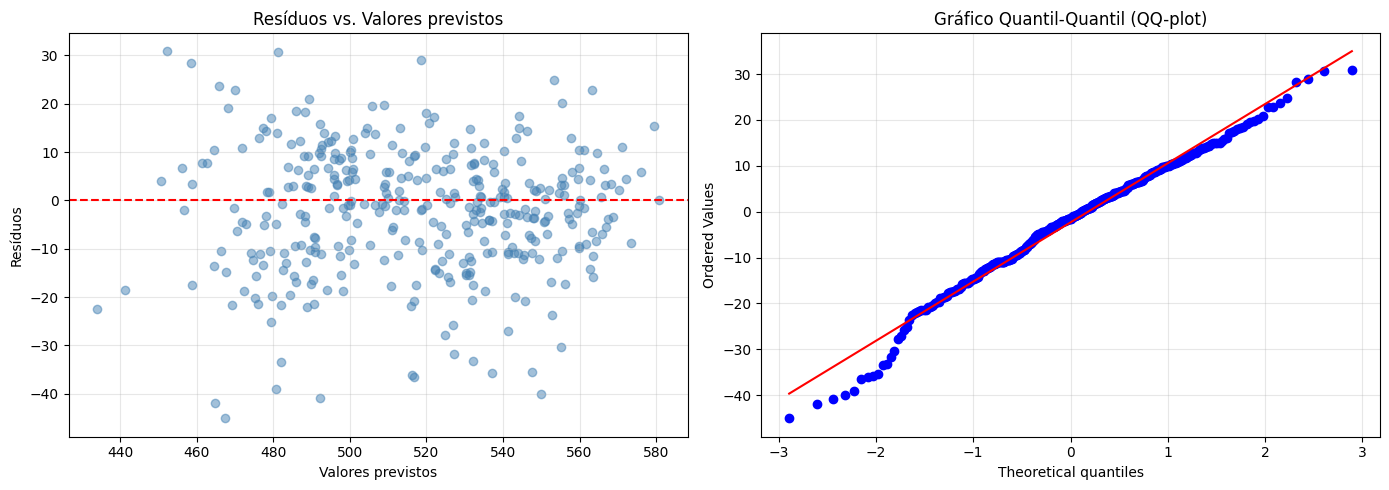

✅ Gráficos gerados com sucesso
📊 Resíduo médio: -2.35
📊 Desvio-padrão dos resíduos: 12.94


In [66]:
import matplotlib.pyplot as plt
from scipy import stats

print("🔍 Calculando e visualizando os resíduos do modelo Ridge")
print("-" * 50)

try:
    residuos_ridge = y_teste - previsoes_ridge

    figura, eixos = plt.subplots(1, 2, figsize=(14, 5))

    eixos[0].scatter(previsoes_ridge, residuos_ridge, alpha=0.5, color="steelblue")
    eixos[0].axhline(y=0, color="red", linestyle="--")
    eixos[0].set_xlabel("Valores previstos")
    eixos[0].set_ylabel("Resíduos")
    eixos[0].set_title("Resíduos vs. Valores previstos")
    eixos[0].grid(alpha=0.3)

    stats.probplot(residuos_ridge, dist="norm", plot=eixos[1])
    eixos[1].set_title("Gráfico Quantil-Quantil (QQ-plot)")
    eixos[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"✅ Gráficos gerados com sucesso")
    print(f"📊 Resíduo médio: {residuos_ridge.mean():.2f}")
    print(f"📊 Desvio-padrão dos resíduos: {residuos_ridge.std():.2f}")

except Exception as erro:
    print(f"❌ Ocorreu um erro: {erro}")

## 🧠 Interpretação: Resíduos do modelo Ridge (especificação final)

O gráfico de resíduos contra valores previstos não revelou padrão sistemático relevante, com a nuvem de pontos distribuída de forma razoavelmente aleatória em torno de zero, compatível com a adequação de uma especificação linear para os dados.

O gráfico quantil-quantil indicou boa aderência à normalidade na região central da distribuição, mas com afastamento perceptível nas caudas, especialmente na cauda inferior, sugerindo a presença de alguns municípios com resíduos mais extremos do que o esperado sob normalidade. O resíduo médio de -2,35 indica um viés pequeno, com o modelo tendendo a superestimar ligeiramente a nota média no conjunto de teste.

Este padrão de caudas pesadas motiva a investigação subsequente de leverage e distância de Cook, para identificar se municípios específicos exercem influência desproporcional sobre o ajuste do modelo.

37.1 - 🔍 Teste formal de normalidade dos resíduos (Shapiro-Wilk)

Complementando a inspeção visual do QQ-plot, esta etapa aplica o teste de Shapiro-Wilk, quantificando formalmente o desvio da normalidade sugerido visualmente pelas caudas do gráfico. Este teste não altera a validade do modelo, já que os erros-padrão robustos HC3 utilizados na Camada 1 não dependem do pressuposto de normalidade dos resíduos.

In [67]:
print("🔍 Testando a normalidade dos resíduos (Shapiro-Wilk)")
print("-" * 50)

try:
    estatistica_sw, p_valor_sw = stats.shapiro(residuos_ridge)
    print(f"📊 Estatística de Shapiro-Wilk: {estatistica_sw:.4f}")
    print(f"📊 P-valor: {p_valor_sw:.2e}")

    if p_valor_sw < 0.05:
        print("⚠️ Rejeita-se a hipótese de normalidade dos resíduos (p < 0,05)")
    else:
        print("✅ Não há evidência para rejeitar a normalidade dos resíduos (p ≥ 0,05)")

except Exception as erro:
    print(f"❌ Ocorreu um erro: {erro}")

🔍 Testando a normalidade dos resíduos (Shapiro-Wilk)
--------------------------------------------------
📊 Estatística de Shapiro-Wilk: 0.9849
📊 P-valor: 8.06e-04
⚠️ Rejeita-se a hipótese de normalidade dos resíduos (p < 0,05)


## 38 - 🎯 Identificação de outliers e pontos de alta influência

Esta etapa identifica municípios que exercem influência desproporcional sobre o ajuste do modelo, combinando leverage e distância de Cook. Estas métricas são matematicamente invariantes à padronização das variáveis preditoras, e por isso o cálculo é realizado diretamente sobre os dados em sua escala original.

In [71]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import OLSInfluence

print("🎯 Calculando leverage e distância de Cook")
print("-" * 50)

try:
    X_treino_com_constante = sm.add_constant(X_treino)
    modelo_auxiliar = sm.WLS(y_treino, X_treino_com_constante, weights=pesos_treino).fit()

    influencia = OLSInfluence(modelo_auxiliar)
    leverage = influencia.hat_matrix_diag
    distancia_cook = influencia.cooks_distance[0]

    n_treino = len(X_treino)
    k_variaveis = X_treino_com_constante.shape[1]
    limite_leverage = 2 * k_variaveis / n_treino
    limite_cook = 4 / n_treino

    indices_treino = X_treino.index
    municipios_treino = tabela_municipio.loc[indices_treino, ["nome_municipio", "uf", "qtd_inscritos", "nota_media_geral"]].copy()
    municipios_treino["leverage"] = leverage
    municipios_treino["distancia_cook"] = distancia_cook

    municipios_leverage_alto = municipios_treino[municipios_treino["leverage"] > limite_leverage]
    municipios_cook_alto = municipios_treino[municipios_treino["distancia_cook"] > limite_cook]

    print(f"📊 Municípios acima do limite de leverage: {len(municipios_leverage_alto)} de {n_treino} ({len(municipios_leverage_alto)/n_treino*100:.1f}%)")
    print(f"📊 Municípios acima do limite de Cook: {len(municipios_cook_alto)} de {n_treino} ({len(municipios_cook_alto)/n_treino*100:.1f}%)")
    print()
    print("📋 Os 10 municípios com maior distância de Cook:")
    print(municipios_treino.sort_values("distancia_cook", ascending=False).head(10).to_string(index=False))

except Exception as erro:
    print(f"❌ Ocorreu um erro: {erro}")

🎯 Calculando leverage e distância de Cook
--------------------------------------------------
📊 Municípios acima do limite de leverage: 0 de 1444 (0.0%)
📊 Municípios acima do limite de Cook: 0 de 1444 (0.0%)

📋 Os 10 municípios com maior distância de Cook:
     nome_municipio uf  qtd_inscritos  nota_media_geral  leverage  distancia_cook
          Tonantins AM            530        396.701833  0.000593    1.694473e-06
Formoso do Araguaia TO            395        476.392509  0.000311    7.573695e-07
      Novo Aripuanã AM            494        428.049363  0.000685    7.255067e-07
          Paraipaba CE           1059        511.425234  0.000750    6.748925e-07
          Parintins AM           4326        472.007007  0.001618    6.303931e-07
            Urucará AM            379        456.335628  0.000623    3.933906e-07
            Canindé CE           2689        515.290672  0.000393    3.273941e-07
             Japurá AM            203        399.985750  0.000489    3.266754e-07
      

## 🧠 Interpretação: Ausência de pontos de alta influência

O diagnóstico realizado não identificou municípios acima dos limites de referência adotados para leverage e distância de Cook. A maior distância de Cook observada foi de aproximadamente 1,69 × 10⁻⁶, enquanto o limite de referência utilizado foi de aproximadamente 0,00277.

Dentro deste diagnóstico, portanto, não foram identificados municípios que apresentassem influência individual elevada sobre o ajuste do modelo.

Os municípios com maiores valores relativos de distância de Cook concentram-se principalmente no estado do Amazonas. Esses municípios devem ser entendidos como observações relativamente atípicas dentro da amostra, mas seus valores de influência permaneceram abaixo do limite de referência utilizado.

A ausência de pontos acima dos limites adotados também indica que os resíduos mais extremos observados anteriormente não parecem estar concentrados em um pequeno número de municípios altamente influentes.

## 39 - 🔍 Robustez da associação em municípios pequenos

Esta etapa investiga se municípios com menor quantidade de participantes se comportam de forma sistematicamente diferente dos demais, tanto em termos de erro do modelo quanto na força da associação central do estudo.

In [80]:
import numpy as np
from scipy import stats

print("🔍 Avaliando a robustez da associação em municípios pequenos")
print("-" * 50)

try:
    tabela_teste_analise = tabela_municipio.loc[X_teste.index, ["nome_municipio", "uf", "qtd_inscritos"]].copy()
    tabela_teste_analise["residuo"] = residuos_ridge.values
    tabela_teste_analise["quartil_tamanho"] = pd.qcut(
        tabela_teste_analise["qtd_inscritos"], q=4, labels=["1º (menores)", "2º", "3º", "4º (maiores)"]
    )

    print("📋 Resíduo médio e desvio-padrão do resíduo, por quartil de tamanho do município:")
    resumo_quartis = tabela_teste_analise.groupby("quartil_tamanho", observed=True).agg(
        qtd_municipios=("residuo", "count"),
        residuo_medio=("residuo", "mean"),
        residuo_desvio=("residuo", "std"),
        menor_qtd_inscritos=("qtd_inscritos", "min"),
        maior_qtd_inscritos=("qtd_inscritos", "max"),
    )
    print(resumo_quartis.to_string())

    print()
    limite_primeiro_quartil = tabela_municipio["qtd_inscritos"].quantile(0.25)
    tabela_sem_pequenos = tabela_municipio[tabela_municipio["qtd_inscritos"] > limite_primeiro_quartil]

    corr_completa, _ = stats.pearsonr(tabela_municipio["pct_sem_computador"], tabela_municipio["nota_media_geral"])
    corr_sem_pequenos, _ = stats.pearsonr(tabela_sem_pequenos["pct_sem_computador"], tabela_sem_pequenos["nota_media_geral"])

    print(f"   Correlação com todos os municípios: r = {corr_completa:.3f}")
    print(f"   Correlação excluindo o 1º quartil: r = {corr_sem_pequenos:.3f}")

except Exception as erro:
    print(f"❌ Ocorreu um erro: {erro}")

🔍 Avaliando a robustez da associação em municípios pequenos
--------------------------------------------------
📋 Resíduo médio e desvio-padrão do resíduo, por quartil de tamanho do município:
                 qtd_municipios  residuo_medio  residuo_desvio  menor_qtd_inscritos  maior_qtd_inscritos
quartil_tamanho                                                                                         
1º (menores)                 91      -8.213332       16.697912                   58                  722
2º                           90      -2.141903       11.620675                  729                 1194
3º                           90      -0.338284       11.613651                 1200                 2260
4º (maiores)                 90       1.378118        8.512940                 2279                85480

   Correlação com todos os municípios: r = -0.877
   Correlação excluindo o 1º quartil: r = -0.905


## 🧠 Interpretação: Robustez da associação em municípios pequenos

A análise de resíduos por quartil de tamanho revelou um padrão sistemático: o modelo superestima, em média, a nota dos municípios menores (resíduo médio de -8,21 no quartil de menor porte) e apresenta viés progressivamente menor nos quartis de maior porte, chegando a um leve viés de subestimação no quartil dos municípios maiores (+1,38). A dispersão do erro também diminui de forma consistente com o aumento do tamanho do município, de um desvio-padrão de 16,70 no primeiro quartil para 8,51 no último.

O teste de sensibilidade indicou que a correlação entre a variável de maior contribuição preditiva e a nota média municipal se torna ligeiramente mais forte ao excluir o quartil de municípios menores (de -0,877 para -0,905), uma diferença de 0,027. A direção dessa mudança indica que os municípios de menor porte introduzem maior dispersão na relação, sem enfraquecer a associação central do estudo; pelo contrário, a associação se mantém robusta e até se intensifica quando a análise é restrita a municípios com maior confiabilidade amostral.

Estes resultados reforçam a adequação da ponderação estatística adotada ao longo do estudo, e indicam que previsões pontuais para municípios de menor porte devem ser interpretadas com cautela adicional, dado o maior viés e a maior dispersão de erro observados nesse subgrupo.

## 40 - 🗺️ Robustez da associação por região do Brasil

Esta etapa verifica se a associação entre vulnerabilidade e desempenho se mantém consistente entre as cinco regiões brasileiras, ou se existe alguma região com comportamento distinto das demais. Cada UF é classificada em sua região oficial, e a correlação entre a variável de maior contribuição preditiva e a nota média municipal é recalculada separadamente para cada uma.

As cinco regiões apresentaram correlação negativa: Sudeste (-0,891), Sul (-0,844), Norte (-0,770), Nordeste (-0,769) e Centro-Oeste (-0,738). As regiões com maior percentual médio de participantes sem computador (Norte e Nordeste) apresentaram as menores notas médias, enquanto as regiões com menor percentual (Sudeste e Sul) apresentaram as maiores notas médias.

In [81]:
from scipy import stats

print("🗺️ Avaliando a robustez da associação por região do Brasil")
print("-" * 50)

try:
    tabela_municipio["regiao"] = tabela_municipio["uf"].map(MAPA_REGIAO)

    for regiao in ["Norte", "Nordeste", "Centro-Oeste", "Sudeste", "Sul"]:
        subset_regiao = tabela_municipio[tabela_municipio["regiao"] == regiao]
        corr, p_valor = stats.pearsonr(subset_regiao["pct_sem_computador"], subset_regiao["nota_media_geral"])
        print(f"📍 {regiao}: {len(subset_regiao)} municípios, r = {corr:.3f}")

except Exception as erro:
    print(f"❌ Ocorreu um erro: {erro}")

🗺️ Avaliando a robustez da associação por região do Brasil
--------------------------------------------------
📍 Norte: 242 municípios, r = -0.770
📍 Nordeste: 656 municípios, r = -0.769
📍 Centro-Oeste: 162 municípios, r = -0.738
📍 Sudeste: 493 municípios, r = -0.891
📍 Sul: 252 municípios, r = -0.844


## 41 - 📍 Robustez da associação por UF

Esta etapa calcula a correlação entre vulnerabilidade e desempenho separadamente para cada UF.

In [82]:
print("📍 Avaliando a robustez da associação por UF")
print("-" * 50)

try:
    resultados_por_uf = []
    for uf in sorted(tabela_municipio["uf"].unique()):
        subset_uf = tabela_municipio[tabela_municipio["uf"] == uf]
        if len(subset_uf) < 5:
            resultados_por_uf.append({"uf": uf, "qtd_municipios": len(subset_uf), "correlacao": None})
            continue
        corr, _ = stats.pearsonr(subset_uf["pct_sem_computador"], subset_uf["nota_media_geral"])
        resultados_por_uf.append({"uf": uf, "qtd_municipios": len(subset_uf), "correlacao": corr})

    df_resultados_uf = pd.DataFrame(resultados_por_uf)
    df_valido = df_resultados_uf[df_resultados_uf["correlacao"].notna()].sort_values("correlacao")
    print(df_valido.to_string(index=False))

except Exception as erro:
    print(f"❌ Ocorreu um erro: {erro}")

📍 Avaliando a robustez da associação por UF
--------------------------------------------------
uf  qtd_municipios  correlacao
RR              10   -0.930486
MG             192   -0.917977
RS             107   -0.900231
AL              27   -0.898078
RN              41   -0.885215
MT              58   -0.870139
RJ              53   -0.866799
SP             210   -0.861744
GO              62   -0.860611
MA              81   -0.859319
ES              38   -0.849292
MS              41   -0.836743
BA             175   -0.831697
TO              31   -0.815604
AP              11   -0.798778
SE              33   -0.798170
PR              89   -0.784685
PB              55   -0.775162
RO              25   -0.746368
PA              89   -0.732261
CE             120   -0.720654
PI              41   -0.718674
PE              83   -0.680051
AM              60   -0.679145
SC              56   -0.596580
AC              16   -0.541788


## 🧠 Interpretação: Robustez por UF

A análise por UF mostrou que todas as 26 unidades da federação com correlação calculável apresentaram associação negativa entre percentual de participantes sem computador e nota média municipal.

As correlações variaram de −0,542 no Acre a −0,930 em Roraima. Embora a direção negativa seja consistente entre as UFs, os tamanhos das amostras estaduais são diferentes e algumas UFs possuem número relativamente pequeno de municípios. Portanto, os resultados devem ser interpretados considerando essa diferença de precisão.

O Distrito Federal não foi incluído na comparação por UF porque possui apenas um município de aplicação da prova.

De forma geral, a manutenção da associação negativa em todas as UFs analisadas reforça a consistência territorial do padrão observado no conjunto nacional.

## 42 - 🗺️ Teste de autocorrelação espacial dos resíduos

Esta etapa verifica se os resíduos do modelo inferencial da Camada 1 (WLS, ajustado com a base completa de municípios, sem partição em treino e teste) apresentam autocorrelação espacial.

As coordenadas geográficas dos municípios são obtidas de uma base pública de municípios brasileiros, utilizada como referência geográfica e cruzada pelo código do município.

A vizinhança espacial é definida pelos k municípios mais próximos, com testes para k = 5, 8 e 15, avaliando a sensibilidade a essa escolha, dada a heterogeneidade de tamanho territorial entre municípios brasileiros. A significância é avaliada por teste de permutação, com 999 repetições.

In [83]:
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors

print("🗺️ Buscando as coordenadas geográficas dos municípios")
print("-" * 50)

try:
    url_coordenadas = "https://raw.githubusercontent.com/kelvins/municipios-brasileiros/main/csv/municipios.csv"
    coordenadas_municipios = pd.read_csv(url_coordenadas)[["codigo_ibge", "latitude", "longitude"]]

    tabela_espacial = tabela_municipio.merge(
        coordenadas_municipios, left_on="codigo_municipio", right_on="codigo_ibge", how="inner"
    )
    print(f"📊 Municípios com coordenada: {len(tabela_espacial):,} de {len(tabela_municipio):,}")

    tabela_espacial["residuo_inferencial"] = modelo_inferencial.resid.reindex(tabela_espacial.index)

    def calcular_indice_moran(valores, indices_vizinhos, k):
        n = len(valores)
        desvios = valores - valores.mean()
        numerador = sum(desvios[i] * desvios[j] for i in range(n) for j in indices_vizinhos[i])
        denominador = np.sum(desvios ** 2)
        return (n / (n * k)) * (numerador / denominador)

    coordenadas_radianos = np.radians(tabela_espacial[["latitude", "longitude"]].values)
    residuos_array = tabela_espacial["residuo_inferencial"].values

    for k in [5, 8, 15]:
        modelo_vizinhos = NearestNeighbors(n_neighbors=k + 1, metric="haversine")
        modelo_vizinhos.fit(coordenadas_radianos)
        _, indices_vizinhos = modelo_vizinhos.kneighbors(coordenadas_radianos)
        indices_vizinhos = indices_vizinhos[:, 1:]

        moran_observado = calcular_indice_moran(residuos_array, indices_vizinhos, k)

        rng = np.random.default_rng(SEMENTE_ALEATORIA_PRINCIPAL)
        moran_permutados = np.array([
            calcular_indice_moran(rng.permutation(residuos_array), indices_vizinhos, k)
            for _ in range(999)
        ])
        p_valor = (np.sum(moran_permutados >= moran_observado) + 1) / (len(moran_permutados) + 1)

        print(f"📊 k = {k}: Índice de Moran = {moran_observado:.4f}, p-valor = {p_valor:.4f}")

except Exception as erro:
    print(f"❌ Ocorreu um erro: {erro}")

🗺️ Buscando as coordenadas geográficas dos municípios
--------------------------------------------------
📊 Municípios com coordenada: 1,805 de 1,805
📊 k = 5: Índice de Moran = 0.5354, p-valor = 0.0010
📊 k = 8: Índice de Moran = 0.5139, p-valor = 0.0010
📊 k = 15: Índice de Moran = 0.4588, p-valor = 0.0010


## 🧠 Interpretação: Autocorrelação espacial dos resíduos

O teste de autocorrelação espacial, aplicado aos resíduos do modelo inferencial da Camada 1 (WLS ajustado na base completa de municípios), identificou autocorrelação espacial positiva e estatisticamente significativa para as três definições de vizinhança testadas: Índice de Moran de 0,5354 (k = 5), 0,5139 (k = 8) e 0,4588 (k = 15), todos com p = 0,001 no teste de permutação. A leve redução do índice à medida que mais vizinhos são considerados é esperada, já que vizinhanças maiores tendem a diluir a similaridade local; ainda assim, a magnitude permanece elevada e a significância estatística não depende da escolha específica de k.

O resultado indica autocorrelação espacial positiva relevante: municípios geograficamente próximos tendem a apresentar resíduos semelhantes.

Isso sugere que existem padrões territoriais no desempenho que não são completamente capturados pelas variáveis socioeconômicas utilizadas no modelo. Esses padrões podem estar relacionados a características regionais, educacionais ou institucionais compartilhadas entre municípios próximos.

A presença de autocorrelação espacial indica que a independência dos resíduos não é plenamente atendida, um resultado consistente com o aumento do erro-padrão observado no Bloco 19.1 ao agrupar por região. Portanto, os resultados do modelo devem ser interpretados com essa limitação em mente, especialmente no que diz respeito à inferência estatística.

Este diagnóstico não invalida a associação encontrada — que se manteve estatisticamente significativa mesmo com erros-padrão clusterizados por região — mas mostra que existe estrutura espacial não capturada pelo modelo. Modelos que incorporem explicitamente a dependência espacial (como SAR ou SEM) poderão ser utilizados em análises futuras para tratar essa dependência de forma mais completa.

# 📊 Síntese dos principais resultados

A análise realizada com os dados do ENEM 2025 encontrou uma associação negativa entre vulnerabilidade socioeconômica e desempenho médio dos municípios analisados.

Os principais resultados foram:

1. O índice exploratório de vulnerabilidade socioeconômica apresentou associação negativa forte com o desempenho municipal.

2. Na regressão WLS, utilizando o número efetivo de participantes como peso e erros-padrão robustos HC3, o índice apresentou coeficiente de aproximadamente −21,47 pontos, com R² = 0,8662 e p < 0,001.

3. A associação permaneceu forte em análises de sensibilidade do índice, incluindo a retirada do componente relacionado à disponibilidade de computador e alteração do peso atribuído à renda.

4. Na modelagem preditiva, os componentes individuais apresentaram maior capacidade preditiva do que o índice agregado.

5. Os modelos lineares WLS, Ridge e Lasso apresentaram desempenho muito semelhante, enquanto o Random Forest apresentou uma vantagem preditiva pequena na média das cinco seeds.

6. A estabilidade por múltiplas seeds mostrou que os resultados não dependem exclusivamente de uma única divisão entre treino e teste.

7. A análise por regiões e UFs manteve a associação negativa em diferentes recortes territoriais.

8. Municípios pequenos apresentaram maior dispersão dos erros de previsão, indicando maior incerteza nesse grupo.

9. A análise dos resíduos não identificou municípios com influência individual elevada segundo os limites adotados.

10. Entretanto, o teste de Moran identificou autocorrelação espacial significativa e robusta à escolha de vizinhança nos resíduos (I entre 0,4588 e 0,5354, conforme k = 15 a k = 5; p = 0,001 em todos os casos), indicando que parte da estrutura territorial do desempenho não é capturada pelas variáveis utilizadas. Uma verificação com erros-padrão clusterizados por região (Bloco 19.1) confirmou que a associação central permanece estatisticamente significativa mesmo sob essa estrutura de dependência mais conservadora.

De forma geral, os resultados são consistentes com a existência de uma associação importante entre condições socioeconômicas e desempenho médio municipal no ENEM 2025. Entretanto, a análise é observacional e agregada ao nível municipal, não permitindo estabelecer relações causais ou generalizar diretamente os resultados para indivíduos.

# ⚠️ Limitações do estudo

Apesar da consistência dos resultados encontrados, algumas limitações devem ser consideradas na interpretação das conclusões.

### 1. Natureza observacional

O estudo utiliza dados observacionais do ENEM 2025. Portanto, as associações encontradas não permitem estabelecer relações de causalidade.

### 2. Nível de agregação

As principais análises são realizadas no nível municipal. Dessa forma, os resultados representam associações entre características médias dos municípios e seu desempenho médio.

Não é possível concluir, a partir desses resultados agregados, que um determinado participante terá necessariamente desempenho menor ou maior em função de suas características individuais.

### 3. Índice exploratório

O índice de vulnerabilidade foi construído especificamente para este estudo e utiliza pesos iguais entre seus componentes. Ele não representa um indicador socioeconômico oficial do INEP e não passou por validação externa.

### 4. Estrutura espacial

O teste de Moran identificou autocorrelação espacial significativa nos resíduos. Isso indica que existe estrutura territorial não capturada pelo modelo e constitui uma limitação para a interpretação da inferência convencional.

### 5. Municípios pequenos

Os municípios com menor número de participantes apresentaram maior dispersão dos erros de previsão. Portanto, as previsões individuais para municípios pequenos devem ser interpretadas com maior cautela.

### 6. Generalização temporal

A análise utiliza dados referentes ao ENEM 2025. Portanto, os resultados não devem ser automaticamente generalizados para outras edições do exame sem nova avaliação.

### 7. Variáveis não observadas

O modelo não contempla todas as características que podem estar relacionadas ao desempenho educacional, como aspectos institucionais, infraestrutura escolar, características regionais, políticas educacionais e outras condições socioeconômicas não disponíveis ou não utilizadas nesta análise.

# ❓ Resposta à pergunta de pesquisa

A pergunta central deste estudo foi: municípios com maior vulnerabilidade socioeconômica apresentam menor desempenho no ENEM?

A resposta, com base nos resultados obtidos, é: sim, os dados analisados apresentam uma associação negativa forte entre vulnerabilidade socioeconômica e desempenho médio municipal no ENEM 2025.

Essa associação se manteve consistente em diferentes especificações do índice, em diferentes modelos preditivos, em diferentes recortes territoriais (regiões e UFs), e permaneceu robusta mesmo após a exclusão de municípios pequenos e a análise por postos (correlação de Spearman).

Entretanto, essa associação não deve ser interpretada como causalidade. O desenho observacional e agregado do estudo, somado à presença de autocorrelação espacial nos resíduos, indica que fatores não observados e estrutura territorial não capturada também estão relacionados ao desempenho municipal.

# 🎯 Conclusão

Os resultados deste estudo indicam uma associação negativa forte entre vulnerabilidade socioeconômica e desempenho médio municipal no ENEM 2025.

A associação permaneceu consistente em diferentes análises de sensibilidade, especificações estatísticas, modelos preditivos e recortes territoriais. Os componentes socioeconômicos individuais apresentaram maior capacidade preditiva do que o índice agregado, enquanto os modelos lineares apresentaram desempenho próximo ao Random Forest.

Ao mesmo tempo, a análise dos resíduos revelou autocorrelação espacial significativa, mostrando que características territoriais não capturadas pelas variáveis utilizadas ainda possuem relação com o desempenho municipal.

Portanto, os resultados sustentam a existência de uma associação importante entre condições socioeconômicas e desempenho educacional médio dos municípios analisados, mas não permitem estabelecer causalidade.

O estudo deve ser interpretado como uma análise observacional de diferenças municipais no ENEM 2025, servindo como evidência quantitativa da relação entre contexto socioeconômico e desempenho educacional e como ponto de partida para análises futuras que incorporem fatores espaciais, institucionais e educacionais adicionais.

## 43 - 📤 Exportação da tabela final para BigQuery / Looker

Esta etapa final exporta a `tabela_municipio` consolidada, no mesmo nível de agregação utilizado ao longo de todo o estudo (um município por linha), para um arquivo único, pronto para upload no BigQuery e conexão com um dashboard no Looker Studio.

O arquivo inclui todas as variáveis socioeconômicas (índice de vulnerabilidade e seus componentes), de desempenho (notas por área e nota média geral) e de peso estatístico utilizadas nas Camadas 1 e 2, permitindo que o dashboard reproduza as mesmas dimensões e métricas analisadas neste notebook. O arquivo é gerado em CSV (compatível com qualquer ferramenta) e, quando possível, também em Parquet (mais leve para upload).

In [ ]:
import os

CAMINHO_TABELA_FINAL_CSV = "/kaggle/working/tabela_municipio_final.csv"
CAMINHO_TABELA_FINAL_PARQUET = "/kaggle/working/tabela_municipio_final.parquet"

print("📤 Exportando a tabela municipal final")
print("-" * 50)

try:
    tabela_municipio.to_csv(CAMINHO_TABELA_FINAL_CSV, index=False)
    tamanho_csv_mb = os.path.getsize(CAMINHO_TABELA_FINAL_CSV) / (1024 * 1024)

    print(f"✅ CSV exportado com sucesso")
    print(f"📊 Total de municípios: {len(tabela_municipio):,}")
    print(f"📊 Total de colunas: {tabela_municipio.shape[1]}")
    print(f"📂 {CAMINHO_TABELA_FINAL_CSV} ({tamanho_csv_mb:.2f} MB)")

except Exception as erro:
    print(f"❌ Ocorreu um erro ao exportar o CSV: {erro}")

# 📦 Parquet é opcional (mais leve para upload), não interrompe o notebook se a biblioteca não estiver disponível
try:
    tabela_municipio.to_parquet(CAMINHO_TABELA_FINAL_PARQUET, index=False)
    tamanho_parquet_mb = os.path.getsize(CAMINHO_TABELA_FINAL_PARQUET) / (1024 * 1024)
    print(f"✅ Parquet exportado com sucesso")
    print(f"📂 {CAMINHO_TABELA_FINAL_PARQUET} ({tamanho_parquet_mb:.2f} MB)")
except Exception as erro:
    print(f"⚠️ Parquet não exportado ({erro}); o CSV acima já é suficiente para o upload")

print()
print("📋 Colunas disponíveis para o dashboard:")
for coluna in tabela_municipio.columns:
    print(f"   - {coluna}")
